## Phase 2: Python EDA

**Data source:** `clean_transactions_full.csv` — exported from MySQL `clean_transactions` view  
**Goal:** Visual exploration of fraud patterns — class imbalance, time, amount, feature correlations  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

FRAUD_COLOR  = "#E24B4A"
LEGIT_COLOR  = "#378ADD"
ACCENT_COLOR = "#1D9E75"
GRAY_COLOR   = "#8C8C8C"
AMBER_COLOR = '#FFA500'
print("Imports done.")

Imports done.


In [2]:
import os

# Method 1: Check if directory exists before changing to it
target_dir = r'C:\Users\grimm\Credit card fraud detection project'

if os.path.exists(target_dir):
    os.chdir(target_dir)
    print('Working from:', os.getcwd())
else:
    print(f"Directory '{target_dir}' does not exist.")
    # Option A: Create the directory if it doesn't exist
    os.makedirs(target_dir, exist_ok=True)
    os.chdir(target_dir)
    print('Created directory and working from:', os.getcwd())

Working from: C:\Users\grimm\Credit card fraud detection project


In [3]:
# Create a proper project folder and move there
project_path = r'C:\Users\grimm\Credit card fraud detection project'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print('Now running from:', os.getcwd())
for folder in ['models', 'outputs/model_charts', 'outputs/eda_charts',
               'outputs/feature_charts', 'data/processed', 'data/raw']:
    os.makedirs(folder, exist_ok=True)
    print(f'  Created: {folder}/')
MODELS_DIR    = 'models'
CHARTS_DIR    = 'outputs/model_charts'
DATA_DIR      = 'data/processed'
PROCESSED_DIR = 'data/processed'
RANDOM_STATE  = 42
print('Paths fixed.')

Now running from: C:\Users\grimm\Credit card fraud detection project
  Created: models/
  Created: outputs/model_charts/
  Created: outputs/eda_charts/
  Created: outputs/feature_charts/
  Created: data/processed/
  Created: data/raw/
Paths fixed.


## 1. Load Data from MySQL Export

We load from the `clean_transactions_full.csv` exported via MySQL `INTO OUTFILE`.  
Note: `INTO OUTFILE` doesn't write headers — we supply column names manually.

In [4]:
# Column names (matches clean_transactions view)
COLS = [
    'Time', 'hour_of_day', 'time_of_day', 'Amount', 'log_amount',
    'V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
    'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
    'V21','V22','V23','V24','V25','V26','V27','V28','Class'
]

#  Load
df = pd.read_csv("clean_transactions_full.csv", header=None, names=COLS)

# Separate fraud / legit for easy access later 
fraud_df = df[df["Class"] == 1].copy()
legit_df = df[df["Class"] == 0].copy()

print(f"Shape        : {df.shape}")
print(f"Legitimate   : {len(legit_df):,}")
print(f"Fraud        : {len(fraud_df):,}")
print(f"Fraud rate   : {len(fraud_df)/len(df)*100:.4f}%")
print(f"Nulls        : {df.isnull().sum().sum()}")
print(f"\nData source  : MySQL clean_transactions view → CSV export")
df.head(3)

Shape        : (284807, 34)
Legitimate   : 284,315
Fraud        : 492
Fraud rate   : 0.1727%
Nulls        : 0

Data source  : MySQL clean_transactions view → CSV export


,Time,hour_of_day,time_of_day,Amount,log_amount,V1,V2,V3,V4,V5,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0,0,Night,149.62,5.014760,-1.359807,-0.072781,2.536347,1.378155,-0.338321,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,0,0,Night,2.69,1.305626,1.191857,0.266151,0.166480,0.448154,0.060018,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1,0,Night,378.66,5.939276,-1.358354,-1.340163,1.773209,0.379780,-0.503198,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0


## 2. Class Imbalance

The single most important observation - drives every modelling decision downstream.

In [5]:
counts      = df["Class"].value_counts().sort_index()
fraud_rate  = counts[1] / len(df) * 100
imbal_ratio = counts[0] // counts[1]

print(f"Legitimate : {counts[0]:,}  ({100-fraud_rate:.2f}%)")
print(f"Fraud      : {counts[1]:,}  ({fraud_rate:.4f}%)")
print(f"Ratio      : {imbal_ratio}:1")
print(f"→ Predicting all-legit gives {100-fraud_rate:.2f}% accuracy — completely useless")

Legitimate : 284,315  (99.83%)
Fraud      : 492  (0.1727%)
Ratio      : 577:1
→ Predicting all-legit gives 99.83% accuracy — completely useless


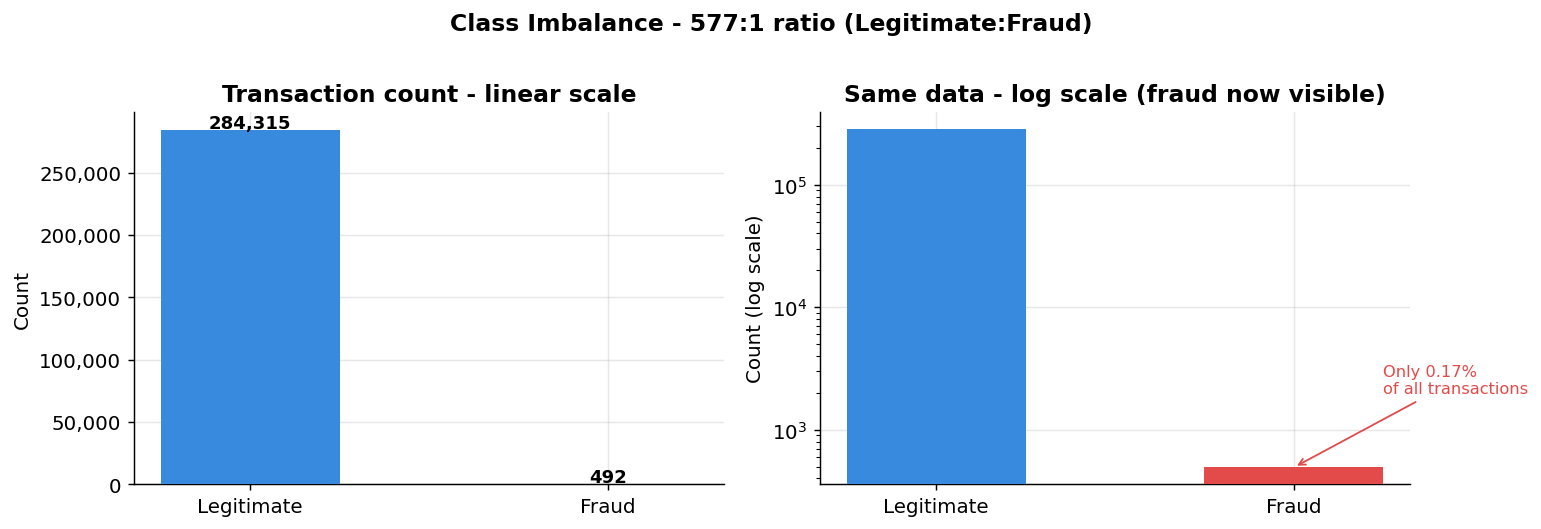

Saved: eda_01_class_imbalance.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax = axes[0]
bars = ax.bar(["Legitimate", "Fraud"], counts.values,
              color=[LEGIT_COLOR, FRAUD_COLOR], width=0.5, zorder=3)
ax.set_title("Transaction count - linear scale")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
            f"{val:,}", ha="center", fontsize=10, fontweight="bold")

# Log scale — makes fraud bar visible
ax = axes[1]
bars = ax.bar(["Legitimate", "Fraud"], counts.values,
              color=[LEGIT_COLOR, FRAUD_COLOR], width=0.5, zorder=3)
ax.set_yscale("log")
ax.set_title("Same data - log scale (fraud now visible)")
ax.set_ylabel("Count (log scale)")
ax.annotate(f"Only {fraud_rate:.2f}%\nof all transactions",
            xy=(1, counts[1]), xytext=(1.25, counts[1]*4),
            fontsize=9, color=FRAUD_COLOR,
            arrowprops=dict(arrowstyle="->", color=FRAUD_COLOR))

plt.suptitle(f"Class Imbalance - {imbal_ratio}:1 ratio (Legitimate:Fraud)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_01_class_imbalance.png", bbox_inches="tight")
plt.show()
print("Saved: eda_01_class_imbalance.png")

## 3. Fraud Patterns by Time of Day

`hour_of_day` and `time_of_day` were computed in MySQL - we just visualise here.

In [7]:
# Hourly stats from the dataframe 
hourly = df.groupby("hour_of_day")["Class"].agg(["sum","count"]).reset_index()
hourly.columns = ["hour", "fraud_count", "total_count"]
hourly["legit_count"] = hourly["total_count"] - hourly["fraud_count"]
hourly["fraud_rate"]  = hourly["fraud_count"] / hourly["total_count"] * 100

peak = hourly.loc[hourly["fraud_rate"].idxmax()]
print(f"Peak fraud hour : {int(peak['hour'])}:00  ({peak['fraud_rate']:.4f}%)")
print()
print(hourly.sort_values("fraud_rate", ascending=False).head(5).to_string(index=False))

Peak fraud hour : 2:00  (1.7127%)

 hour  fraud_count  total_count  legit_count  fraud_rate
    2           57         3328         3271    1.712740
    4           23         2209         2186    1.041195
    3           17         3492         3475    0.486827
    5           11         2990         2979    0.367893
    7           23         7243         7220    0.317548


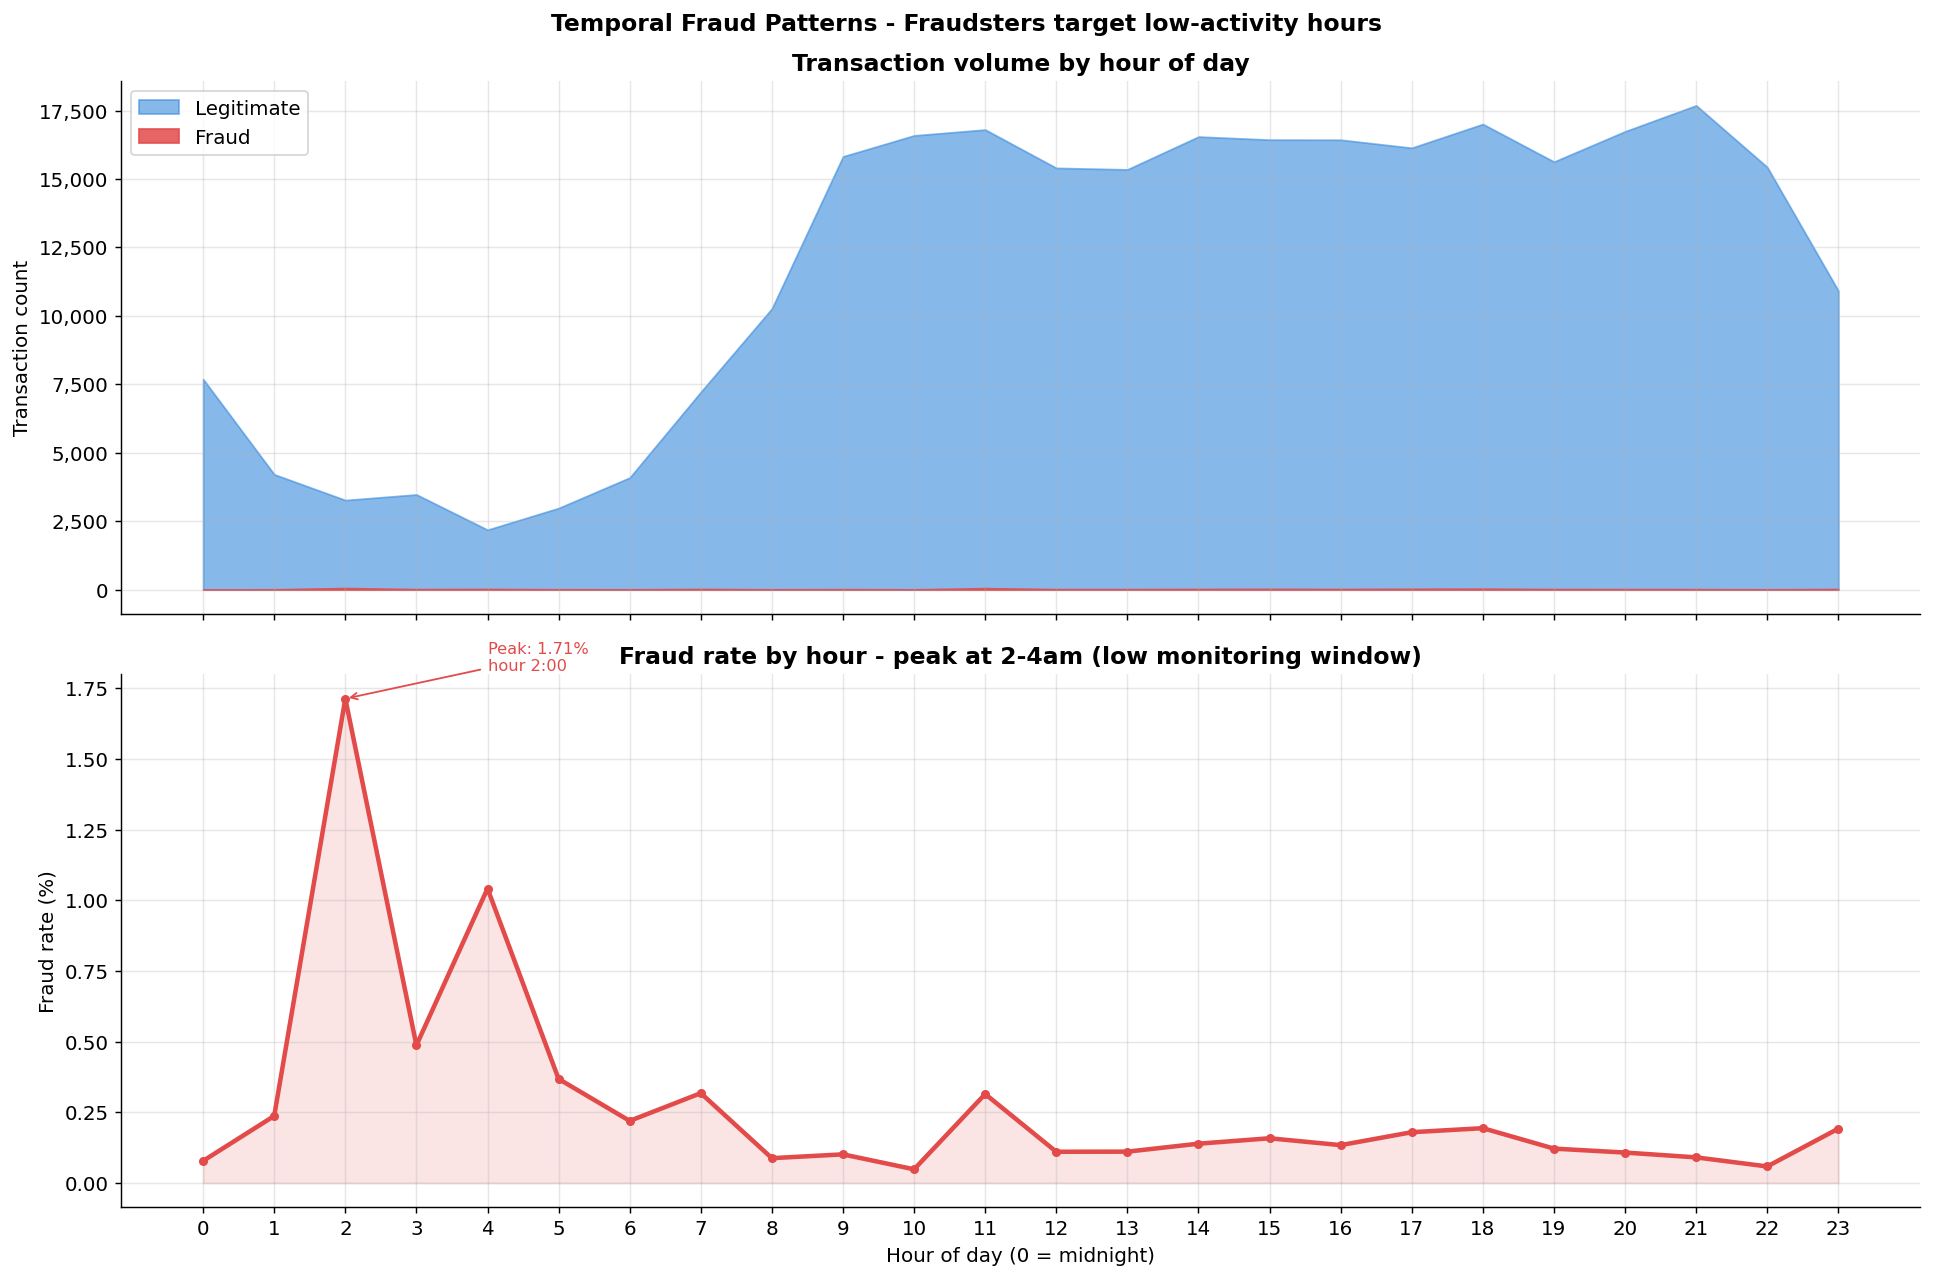

Saved: eda_02_fraud_by_hour.png


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Volume
ax1.fill_between(hourly["hour"], hourly["legit_count"],
                 alpha=0.6, color=LEGIT_COLOR, label="Legitimate")
ax1.fill_between(hourly["hour"], hourly["fraud_count"],
                 alpha=0.85, color=FRAUD_COLOR, label="Fraud")
ax1.set_ylabel("Transaction count")
ax1.set_title("Transaction volume by hour of day")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# Fraud rate
ax2.plot(hourly["hour"], hourly["fraud_rate"],
         color=FRAUD_COLOR, linewidth=2.5, marker="o", markersize=4, zorder=3)
ax2.fill_between(hourly["hour"], hourly["fraud_rate"],
                 alpha=0.15, color=FRAUD_COLOR)
ax2.set_xlabel("Hour of day (0 = midnight)")
ax2.set_ylabel("Fraud rate (%)")
ax2.set_title("Fraud rate by hour - peak at 2-4am (low monitoring window)")
ax2.set_xticks(range(0, 24))

ax2.annotate(f"Peak: {peak['fraud_rate']:.2f}%\nhour {int(peak['hour'])}:00",
             xy=(peak["hour"], peak["fraud_rate"]),
             xytext=(peak["hour"]+2, peak["fraud_rate"]+0.1),
             fontsize=9, color=FRAUD_COLOR,
             arrowprops=dict(arrowstyle="->", color=FRAUD_COLOR))

plt.suptitle("Temporal Fraud Patterns - Fraudsters target low-activity hours",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_02_fraud_by_hour.png", bbox_inches="tight")
plt.show()
print("Saved: eda_02_fraud_by_hour.png")

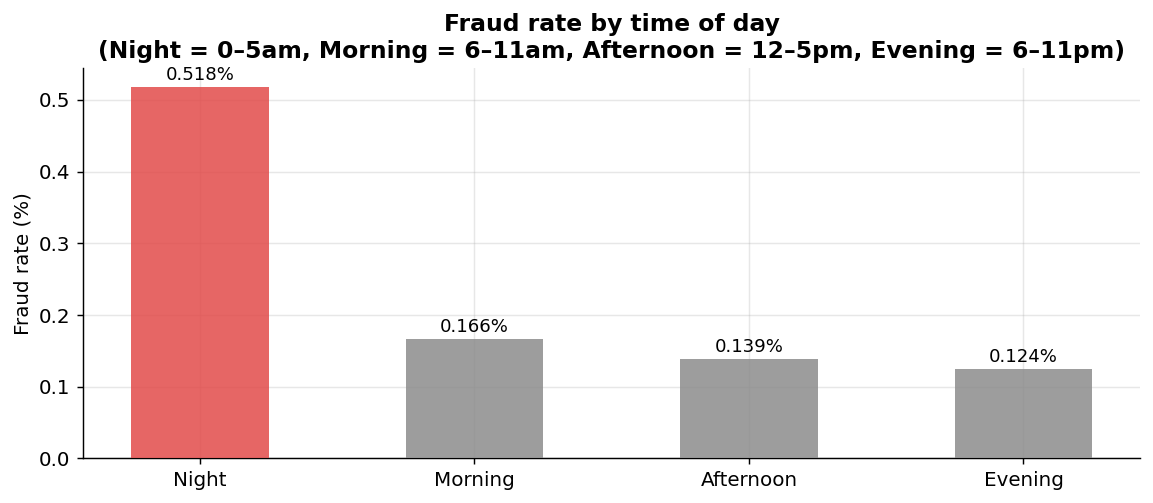

Saved: eda_03_fraud_by_timeofday.png


In [9]:
#  time_of_day breakdown (from MySQL CASE WHEN) 
tod_order = ["Night", "Morning", "Afternoon", "Evening"]
tod = df.groupby("time_of_day")["Class"].agg(["sum","count"]).reset_index()
tod.columns = ["time_of_day","fraud","total"]
tod["fraud_rate"] = tod["fraud"] / tod["total"] * 100
tod["time_of_day"] = pd.Categorical(tod["time_of_day"], categories=tod_order, ordered=True)
tod = tod.sort_values("time_of_day")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(tod["time_of_day"], tod["fraud_rate"],
              color=[FRAUD_COLOR if r == tod["fraud_rate"].max() else GRAY_COLOR
                     for r in tod["fraud_rate"]],
              alpha=0.85, zorder=3, width=0.5)
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by time of day\n(Night = 0–5am, Morning = 6–11am, Afternoon = 12–5pm, Evening = 6–11pm)")
for bar, val in zip(bars, tod["fraud_rate"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_03_fraud_by_timeofday.png", bbox_inches="tight")
plt.show()
print("Saved: eda_03_fraud_by_timeofday.png")

## 4. Transaction Amount Analysis

In [10]:
# Amount stats: fraud vs legit 
stats = pd.DataFrame({
    "Metric": ["Mean", "Median", "Std Dev", "Max", "% under $100"],
    "Legitimate": [
        f"${legit_df['Amount'].mean():.2f}",
        f"${legit_df['Amount'].median():.2f}",
        f"${legit_df['Amount'].std():.2f}",
        f"${legit_df['Amount'].max():.2f}",
        f"{(legit_df['Amount'] < 100).mean()*100:.1f}%"
    ],
    "Fraud": [
        f"${fraud_df['Amount'].mean():.2f}",
        f"${fraud_df['Amount'].median():.2f}",
        f"${fraud_df['Amount'].std():.2f}",
        f"${fraud_df['Amount'].max():.2f}",
        f"{(fraud_df['Amount'] < 100).mean()*100:.1f}%"
    ]
})
print(stats.to_string(index=False))

      Metric Legitimate    Fraud
        Mean     $88.29  $122.21
      Median     $22.00    $9.25
     Std Dev    $250.11  $256.68
         Max  $25691.16 $2125.87
% under $100      79.9%    73.6%


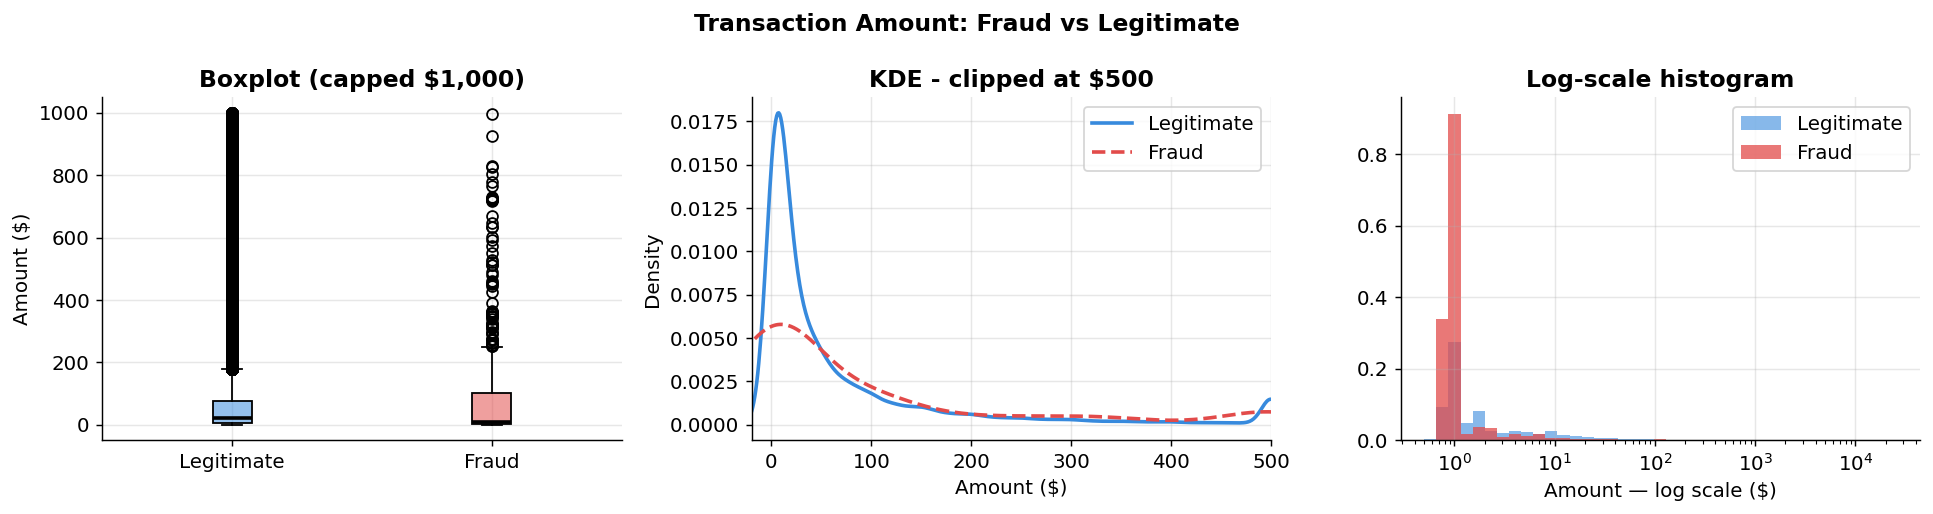

Saved: eda_04_amount_distribution.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
ax = axes[0]
bp = ax.boxplot(
    [legit_df["Amount"][legit_df["Amount"] < 1000],
     fraud_df["Amount"][fraud_df["Amount"] < 1000]],
    labels=["Legitimate", "Fraud"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
bp["boxes"][0].set_facecolor(LEGIT_COLOR + "88")
bp["boxes"][1].set_facecolor(FRAUD_COLOR + "88")
ax.set_ylabel("Amount ($)")
ax.set_title("Boxplot (capped $1,000)")

# KDE
ax = axes[1]
legit_df["Amount"].clip(upper=500).plot.kde(
    ax=ax, color=LEGIT_COLOR, label="Legitimate", linewidth=2)
fraud_df["Amount"].clip(upper=500).plot.kde(
    ax=ax, color=FRAUD_COLOR, label="Fraud", linewidth=2, linestyle="--")
ax.set_xlim(-20, 500)
ax.set_xlabel("Amount ($)")
ax.set_title("KDE - clipped at $500")
ax.legend()

# Log-scale histogram
ax = axes[2]
bins = np.logspace(np.log10(0.5), np.log10(df["Amount"].max()+1), 40)
ax.hist(legit_df["Amount"]+0.01, bins=bins, alpha=0.6,
        color=LEGIT_COLOR, label="Legitimate", density=True)
ax.hist(fraud_df["Amount"]+0.01, bins=bins, alpha=0.75,
        color=FRAUD_COLOR, label="Fraud",      density=True)
ax.set_xscale("log")
ax.set_xlabel("Amount — log scale ($)")
ax.set_title("Log-scale histogram")
ax.legend()

plt.suptitle("Transaction Amount: Fraud vs Legitimate",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_04_amount_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: eda_04_amount_distribution.png")

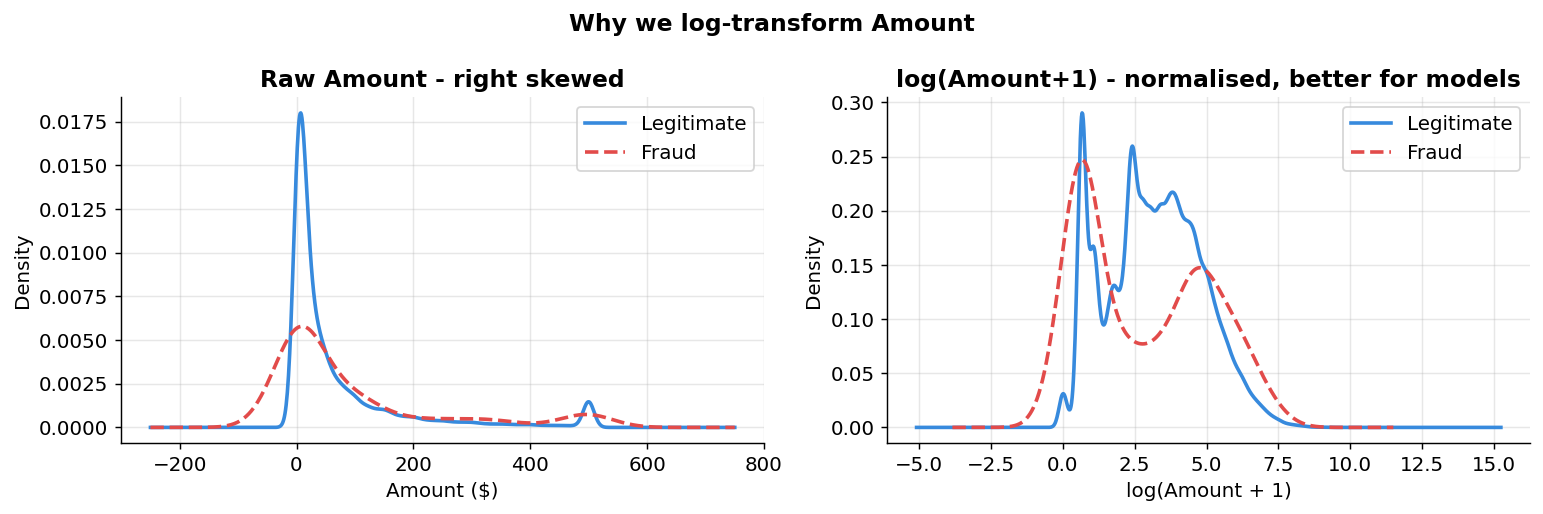

Saved: eda_05_log_amount.png


In [12]:
# log_amount comparison (already computed in MySQL) 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
legit_df["Amount"].clip(upper=500).plot.kde(
    ax=ax, color=LEGIT_COLOR, label="Legitimate", linewidth=2)
fraud_df["Amount"].clip(upper=500).plot.kde(
    ax=ax, color=FRAUD_COLOR, label="Fraud", linewidth=2, linestyle="--")
ax.set_title("Raw Amount - right skewed")
ax.set_xlabel("Amount ($)")
ax.legend()

ax = axes[1]
legit_df["log_amount"].plot.kde(
    ax=ax, color=LEGIT_COLOR, label="Legitimate", linewidth=2)
fraud_df["log_amount"].plot.kde(
    ax=ax, color=FRAUD_COLOR, label="Fraud", linewidth=2, linestyle="--")
ax.set_title("log(Amount+1) - normalised, better for models")
ax.set_xlabel("log(Amount + 1)")
ax.legend()

plt.suptitle("Why we log-transform Amount",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_05_log_amount.png", bbox_inches="tight")
plt.show()
print("Saved: eda_05_log_amount.png")

## 5. Feature Correlation with Fraud (V1 - V28)

In [13]:
v_features = [f"V{i}" for i in range(1, 29)]
correlations = df[v_features + ["Amount", "log_amount", "hour_of_day"]]\
               .corrwith(df["Class"])\
               .sort_values(key=abs, ascending=False)

print("Top 10 features correlated with fraud:")
print(correlations.head(10).round(4).to_string())

Top 10 features correlated with fraud:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V11    0.1549
V4     0.1334
V18   -0.1115


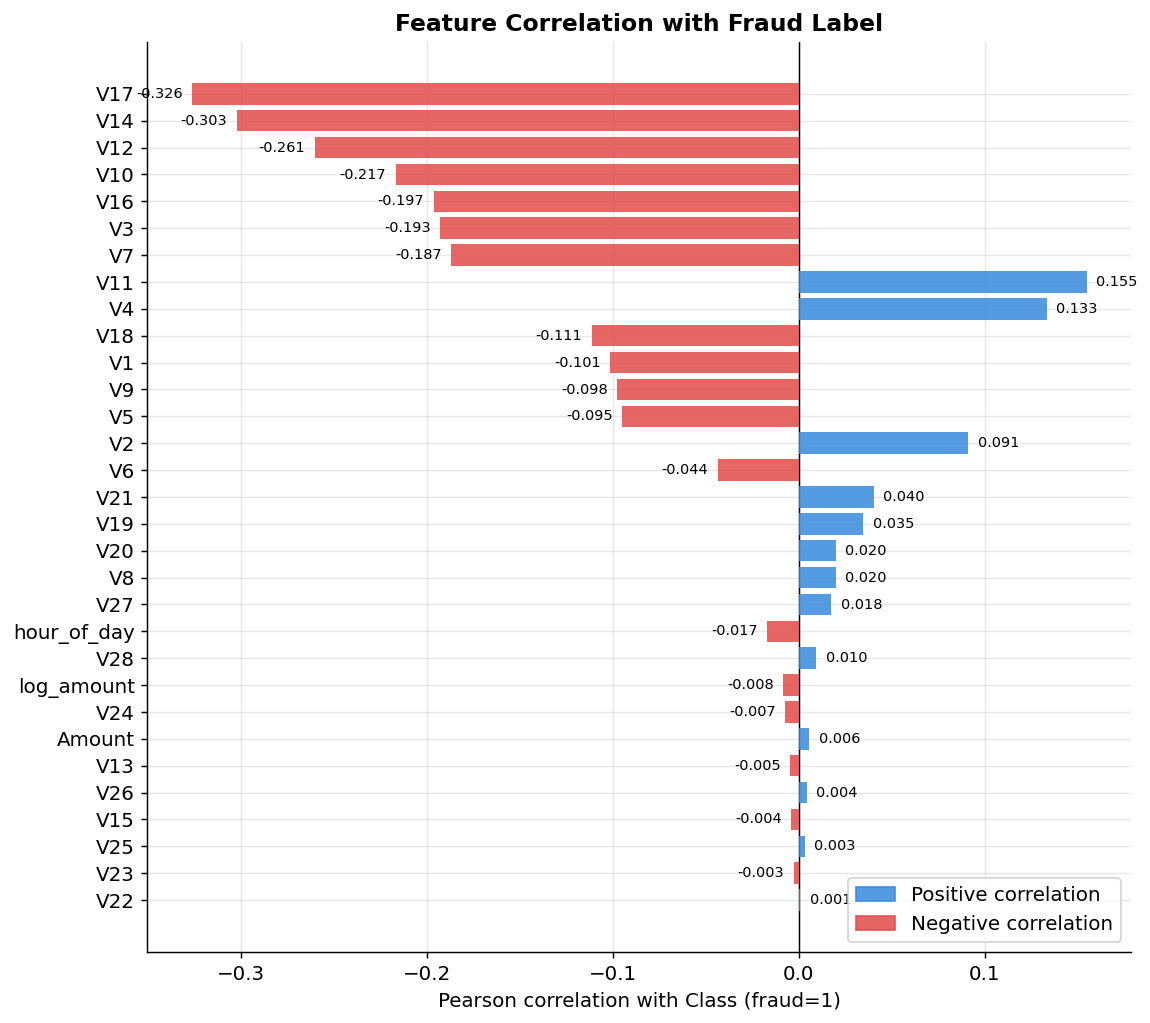

Saved: eda_06_feature_correlations.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 8))

colors = [FRAUD_COLOR if c < 0 else LEGIT_COLOR for c in correlations.values]
bars = ax.barh(correlations.index, correlations.values,
               color=colors, alpha=0.85, zorder=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Class (fraud=1)")
ax.set_title("Feature Correlation with Fraud Label",
             fontweight="bold")
ax.invert_yaxis()

for bar, val in zip(bars, correlations.values):
    x = bar.get_width()
    ax.text(x + (0.005 if x >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="left" if x >= 0 else "right", fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=LEGIT_COLOR, alpha=0.85, label="Positive correlation"),
    Patch(color=FRAUD_COLOR, alpha=0.85, label="Negative correlation")
], loc="lower right")

plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_06_feature_correlations.png", bbox_inches="tight")
plt.show()
print("Saved: eda_06_feature_correlations.png")

## 6. KDE Separation - Top 6 Predictive Features

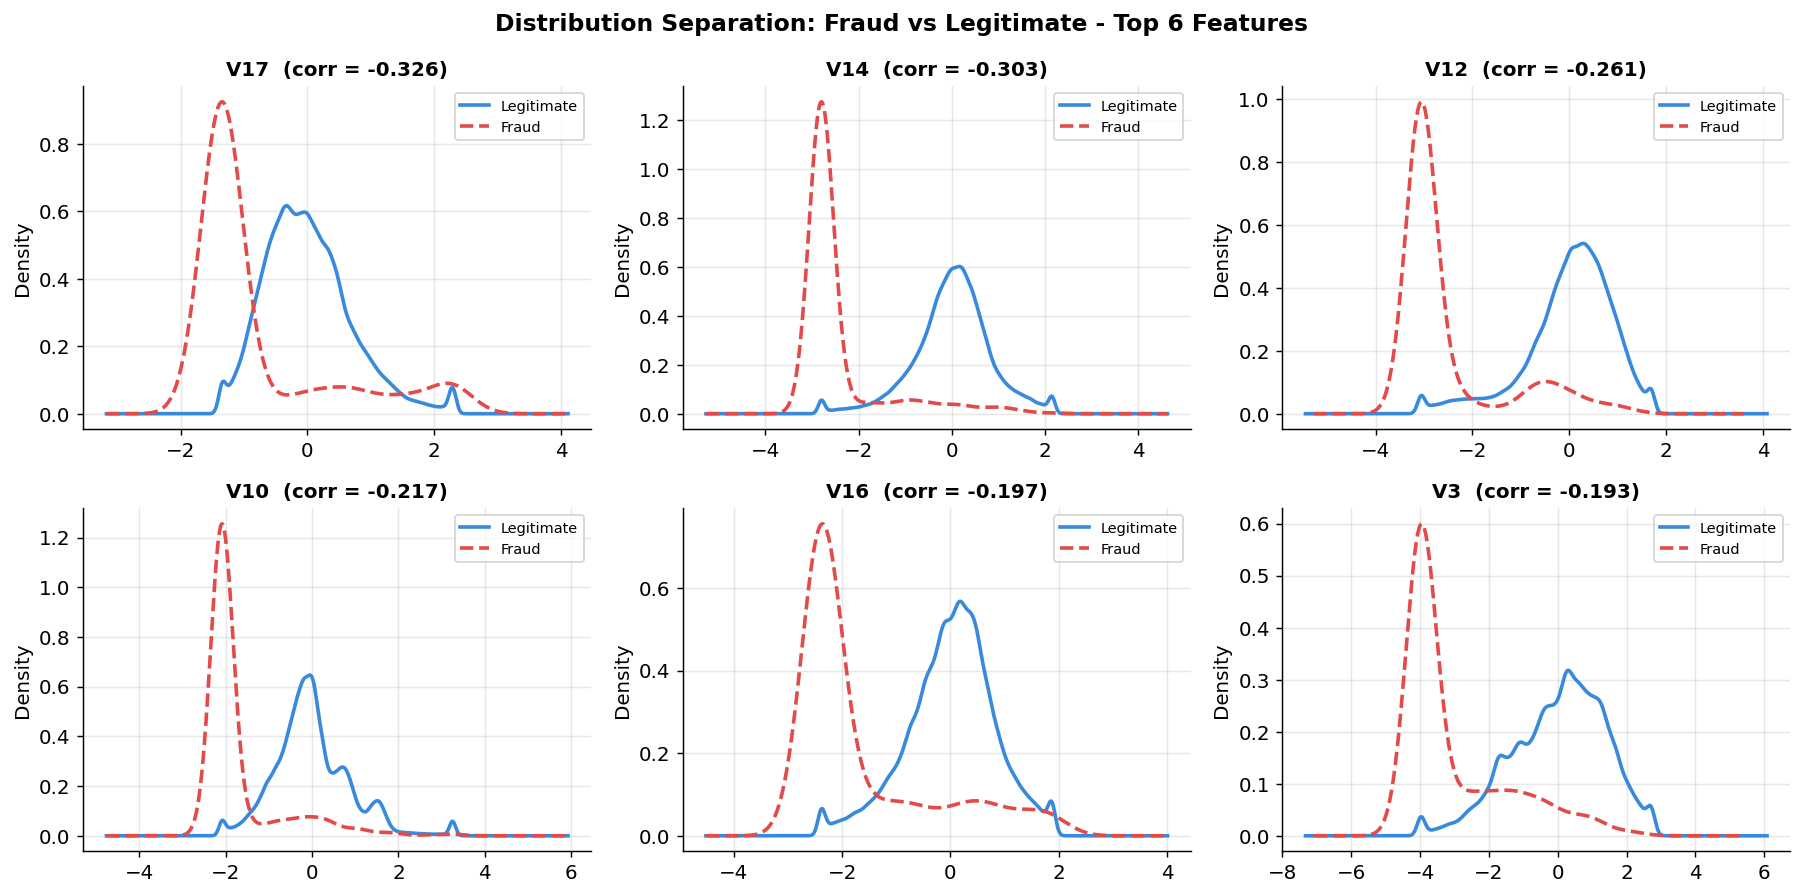

Saved: eda_07_kde_separation.png


In [15]:
top6 = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, top6):
    lo = df[feat].quantile(0.01)
    hi = df[feat].quantile(0.99)
    legit_df[feat].clip(lo, hi).plot.kde(
        ax=ax, color=LEGIT_COLOR, label="Legitimate", linewidth=2)
    fraud_df[feat].clip(lo, hi).plot.kde(
        ax=ax, color=FRAUD_COLOR, label="Fraud",
        linewidth=2, linestyle="--")
    corr_val = correlations[feat]
    ax.set_title(f"{feat}  (corr = {corr_val:.3f})", fontsize=11)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Distribution Separation: Fraud vs Legitimate - Top 6 Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_07_kde_separation.png", bbox_inches="tight")
plt.show()
print("Saved: eda_07_kde_separation.png")

## 7. Correlation Heatmap

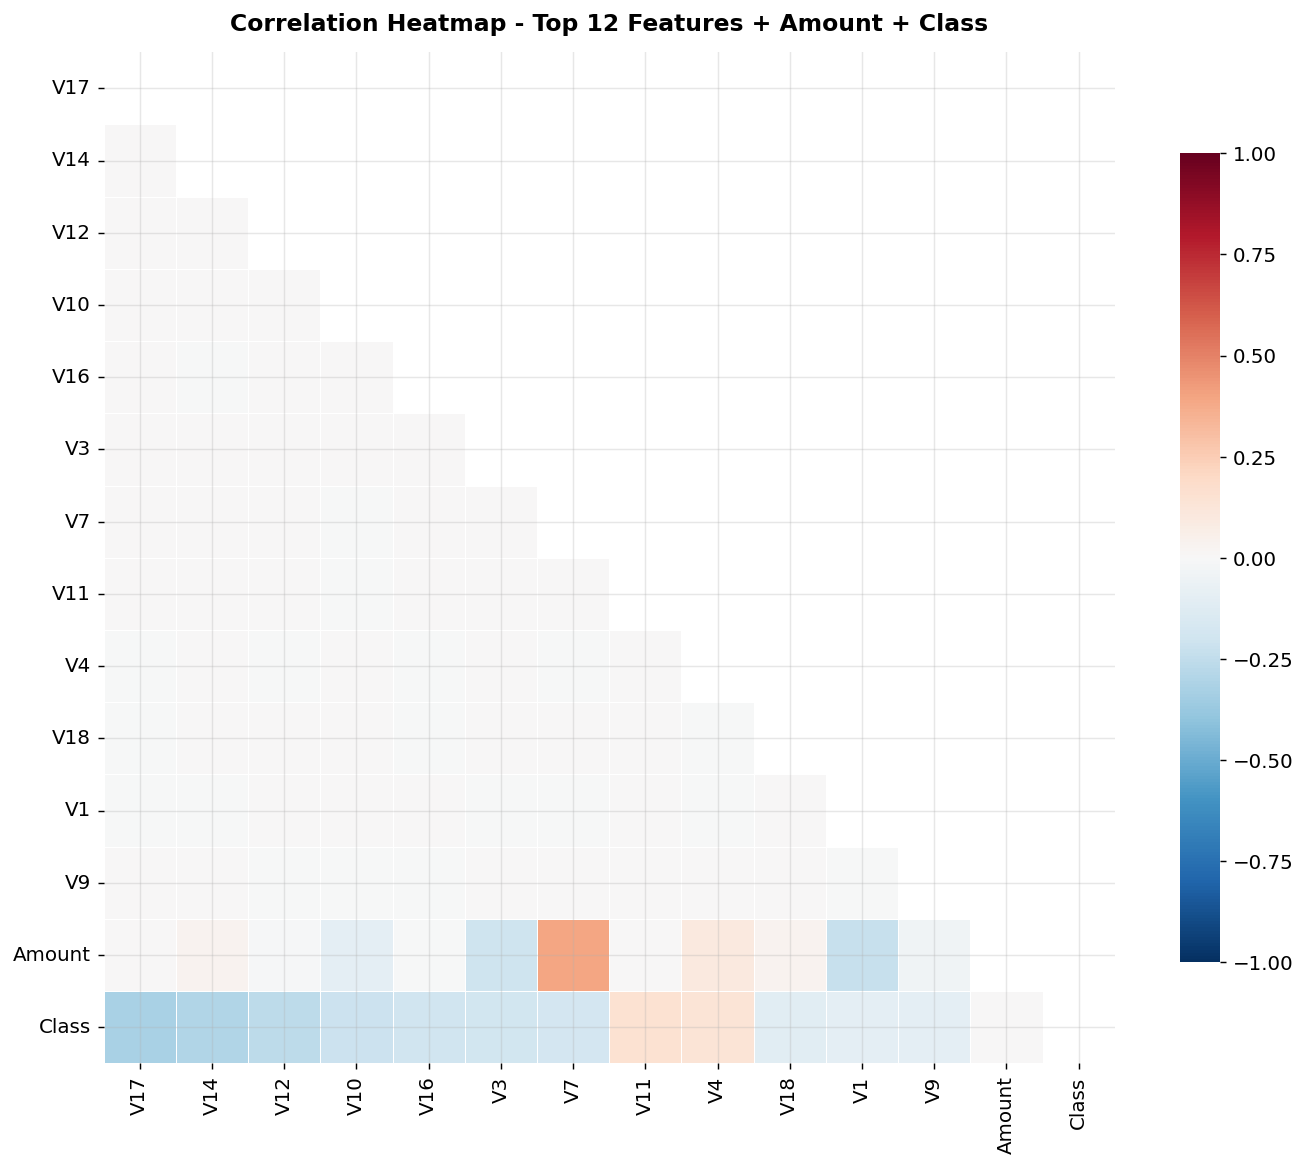

Saved: eda_08_correlation_heatmap.png


In [16]:
top12 = correlations.head(12).index.tolist() + ["Amount", "Class"]
corr_matrix = df[top12].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=False, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)
ax.set_title("Correlation Heatmap - Top 12 Features + Amount + Class",
             fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\eda_charts\eda_08_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: eda_08_correlation_heatmap.png")

## 8. EDA Summary

In [17]:
peak_hour    = int(hourly.loc[hourly["fraud_rate"].idxmax(), "hour"])
peak_rate    = hourly["fraud_rate"].max()
low_amt_pct  = (fraud_df["Amount"] < 100).mean() * 100
top5_feats   = ", ".join(correlations.head(5).index.tolist())

print("=" * 56)
print("  PHASE 2 EDA SUMMARY")
print("=" * 56)
print(f"  Dataset        : {len(df):,} transactions, {df.shape[1]} features")
print(f"  Fraud cases    : {len(fraud_df):,} ({len(fraud_df)/len(df)*100:.4f}%)")
print(f"  Imbalance      : {len(legit_df)//len(fraud_df)}:1")
print()
print("  TEMPORAL PATTERNS")
print(f"  Peak hour      : {peak_hour}:00  ({peak_rate:.4f}% fraud rate)")
print(f"  Riskiest period: Night (0–5am)")
print()
print("  AMOUNT PATTERNS")
print(f"  Avg fraud amt  : ${fraud_df['Amount'].mean():.2f}")
print(f"  Avg legit amt  : ${legit_df['Amount'].mean():.2f}")
print(f"  Fraud < $100   : {low_amt_pct:.1f}% (card-testing pattern)")
print()
print("  TOP FEATURES (by |correlation| with fraud)")
for feat, corr in correlations.head(5).items():
    print(f"  {feat:15s}: {corr:+.4f}")
print()
print("  CHARTS SAVED")
for i, name in enumerate([
    "Class imbalance", "Fraud by hour", "Fraud by time-of-day",
    "Amount distributions", "Log-amount transform",
    "Feature correlations", "KDE separation", "Heatmap"
], 1):
    print(f"  eda_{i:02d} — {name}")
print()
print("  NEXT → Phase 3: Feature Engineering")
print("  velocity features · amt_zscore · is_night flag")
print("=" * 56)

  PHASE 2 EDA SUMMARY
  Dataset        : 284,807 transactions, 34 features
  Fraud cases    : 492 (0.1727%)
  Imbalance      : 577:1

  TEMPORAL PATTERNS
  Peak hour      : 2:00  (1.7127% fraud rate)
  Riskiest period: Night (0–5am)

  AMOUNT PATTERNS
  Avg fraud amt  : $122.21
  Avg legit amt  : $88.29
  Fraud < $100   : 73.6% (card-testing pattern)

  TOP FEATURES (by |correlation| with fraud)
  V17            : -0.3265
  V14            : -0.3025
  V12            : -0.2606
  V10            : -0.2169
  V16            : -0.1965

  CHARTS SAVED
  eda_01 — Class imbalance
  eda_02 — Fraud by hour
  eda_03 — Fraud by time-of-day
  eda_04 — Amount distributions
  eda_05 — Log-amount transform
  eda_06 — Feature correlations
  eda_07 — KDE separation
  eda_08 — Heatmap

  NEXT → Phase 3: Feature Engineering
  velocity features · amt_zscore · is_night flag


# Phase 3: Feature Engineering

**Goal:** Build new features from raw data that give the model stronger fraud signal.  
**Input:** `clean_transactions_full.csv` from MySQL export  
**Output:** `featured_transactions.csv` - enriched dataset ready for modelling  

| Feature | Type | Rationale |
|---|---|---|
| `is_night` | Binary | Fraud peaks 0-5am |
| `amt_zscore` | Continuous | Flags unusually large/small amounts |
| `amt_bucket` | Ordinal | Card-testing pattern |
| `txn_velocity_1h` | Continuous | Multiple txns in short window |
| `txn_velocity_10m` | Continuous | 10-minute window velocity |
| `rapid_repeat` | Binary | 3+ txns in 10 minutes |
| `time_sin/cos` | Cyclical | Encodes hour as cyclical |

---

In [18]:
df = df.sort_values('Time').reset_index(drop=True)

print(f'Loaded  : {len(df):,} rows x {df.shape[1]} cols')
print(f'Fraud   : {df["Class"].sum():,}')
df[['Time','hour_of_day','time_of_day','Amount','log_amount','Class']].head(10)

Loaded  : 284,807 rows x 34 cols
Fraud   : 492


,Time,hour_of_day,time_of_day,Amount,log_amount,Class
0,0,0,Night,149.62,5.014760,0
1,0,0,Night,2.69,1.305626,0
2,1,0,Night,378.66,5.939276,0
3,1,0,Night,123.50,4.824306,0
4,2,0,Night,69.99,4.262539,0
5,2,0,Night,3.67,1.541159,0
6,4,0,Night,4.99,1.790091,0
7,7,0,Night,40.80,3.732896,0
8,7,0,Night,93.20,4.545420,0
9,9,0,Night,3.68,1.543298,0


## Feature 1 — `is_night` (Binary)
EDA showed fraud rate is highest 0-5am. A binary flag lets the model weight night transactions differently.

In [19]:
df['is_night'] = (df['hour_of_day'].between(0, 5)).astype(int)

night_rate = df[df['is_night']==1]['Class'].mean() * 100
day_rate   = df[df['is_night']==0]['Class'].mean() * 100

print(f'Fraud rate Night (0-5am) : {night_rate:.4f}%')
print(f'Fraud rate Day           : {day_rate:.4f}%')
print(f'Night is {night_rate/day_rate:.1f}x riskier than day')

Fraud rate Night (0-5am) : 0.5181%
Fraud rate Day           : 0.1411%
Night is 3.7x riskier than day


## Feature 2 — `amt_zscore` (Continuous)
Z-score flags how far a transaction deviates from the mean. Fraud = extreme amounts (very small card-testing OR very large).

In [20]:
amt_mean = df['Amount'].mean()
amt_std  = df['Amount'].std()
df['amt_zscore'] = (df['Amount'] - amt_mean) / amt_std

fraud_z = df[df['Class']==1]['amt_zscore']
legit_z = df[df['Class']==0]['amt_zscore']

print(f'Amount mean : ${amt_mean:.2f}  |  std : ${amt_std:.2f}')
print()
print('amt_zscore comparison:')
stats = pd.DataFrame({
    'Metric'      : ['Mean','Median','Std','|zscore|>2 %'],
    'Legitimate'  : [f'{legit_z.mean():.3f}', f'{legit_z.median():.3f}',
                     f'{legit_z.std():.3f}',  f'{(legit_z.abs()>2).mean()*100:.2f}%'],
    'Fraud'       : [f'{fraud_z.mean():.3f}', f'{fraud_z.median():.3f}',
                     f'{fraud_z.std():.3f}',  f'{(fraud_z.abs()>2).mean()*100:.2f}%'],
})
print(stats.to_string(index=False))

Amount mean : $88.35  |  std : $250.12

amt_zscore comparison:
      Metric Legitimate  Fraud
        Mean     -0.000  0.135
      Median     -0.265 -0.316
         Std      1.000  1.026
|zscore|>2 %      2.56%  5.89%


## Feature 3 — `amt_bucket` (Ordinal)
SQL Phase 1 confirmed card-testing pattern in $10-$99. Encoded as ordinal integer 0-5.

In [21]:
def amount_bucket(amt):
    if   amt < 10:  return 0
    elif amt < 50:  return 1
    elif amt < 100: return 2
    elif amt < 200: return 3
    elif amt < 500: return 4
    else:           return 5

df['amt_bucket'] = df['Amount'].apply(amount_bucket)

bucket_labels = ['<$10','$10-49','$50-99','$100-199','$200-499','$500+']
bucket_stats  = df.groupby('amt_bucket')['Class'].agg(['sum','count']).reset_index()
bucket_stats['fraud_rate'] = bucket_stats['sum'] / bucket_stats['count'] * 100
bucket_stats['label']      = bucket_labels

print('Fraud rate by amount bucket:')
print(bucket_stats[['label','count','sum','fraud_rate']]
      .rename(columns={'sum':'fraud','count':'total'}).to_string(index=False))

Fraud rate by amount bucket:
   label  total  fraud  fraud_rate
    <$10  97314    249    0.255873
  $10-49  92390     56    0.060613
  $50-99  37718     57    0.151121
$100-199  28070     45    0.160314
$200-499  19823     50    0.252232
   $500+   9492     35    0.368732


## Feature 4 — Velocity Features (`txn_velocity_1h`, `txn_velocity_10m`, `rapid_repeat`)
Velocity = transactions per time window. Proxy for card-testing behaviour.

> In production : `COUNT(*) OVER (PARTITION BY card_id ORDER BY txn_time RANGE INTERVAL 1 HOUR PRECEDING)`

In [22]:
df['hour_bucket']    = (df['Time'] // 3600).astype(int)
df['ten_min_bucket'] = (df['Time'] // 600).astype(int)

df['txn_velocity_1h']  = df.groupby('hour_bucket')['Class'].transform('count')
df['txn_velocity_10m'] = df.groupby('ten_min_bucket')['Class'].transform('count')
df['rapid_repeat']     = (df['txn_velocity_10m'] >= 3).astype(int)

print('txn_velocity_1h:')
print(f'  Fraud mean  : {df[df["Class"]==1]["txn_velocity_1h"].mean():.1f} txns/hr')
print(f'  Legit mean  : {df[df["Class"]==0]["txn_velocity_1h"].mean():.1f} txns/hr')
print()
rr_fraud = df[df['rapid_repeat']==1]['Class'].mean() * 100
rr_norm  = df[df['rapid_repeat']==0]['Class'].mean() * 100
print(f'rapid_repeat fraud rate when 1 : {rr_fraud:.4f}%')
print(f'rapid_repeat fraud rate when 0 : {rr_norm:.4f}%')

txn_velocity_1h:
  Fraud mean  : 6094.2 txns/hr
  Legit mean  : 7296.0 txns/hr

rapid_repeat fraud rate when 1 : 0.1727%
rapid_repeat fraud rate when 0 : nan%


## Feature 5 — Cyclical Time Encoding (`time_sin`, `time_cos`)
Without cyclical encoding, model treats hour 23 and hour 0 as 23 units apart — but they are only 1 hour apart.

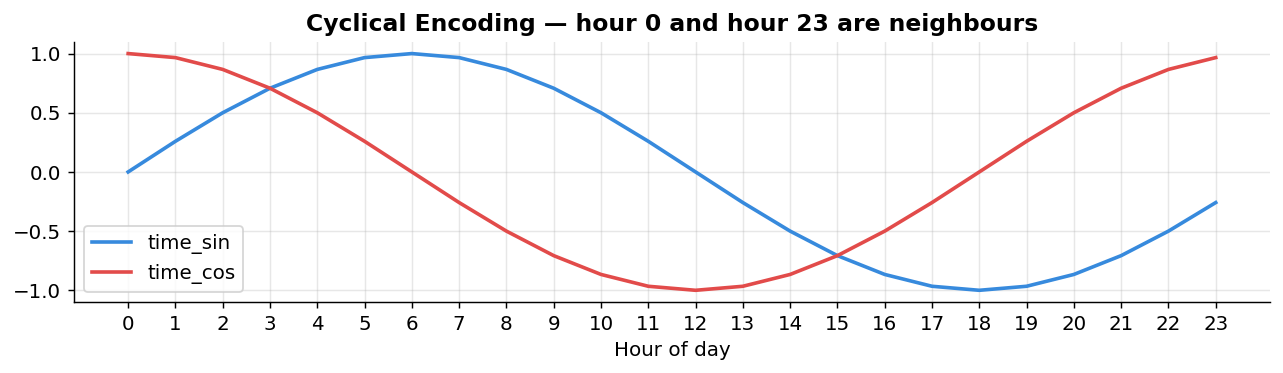

Saved: feat_01_cyclical_encoding.png


In [23]:
df['time_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['time_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

fig, ax = plt.subplots(figsize=(10, 3))
hours = np.arange(0, 24)
ax.plot(hours, np.sin(2*np.pi*hours/24), label='time_sin', color=LEGIT_COLOR, linewidth=2)
ax.plot(hours, np.cos(2*np.pi*hours/24), label='time_cos', color=FRAUD_COLOR, linewidth=2)
ax.set_xticks(hours)
ax.set_xlabel('Hour of day')
ax.set_title('Cyclical Encoding — hour 0 and hour 23 are neighbours')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\feature_charts\feat_01_cyclical_encoding.png", bbox_inches='tight')
plt.show()
print('Saved: feat_01_cyclical_encoding.png')

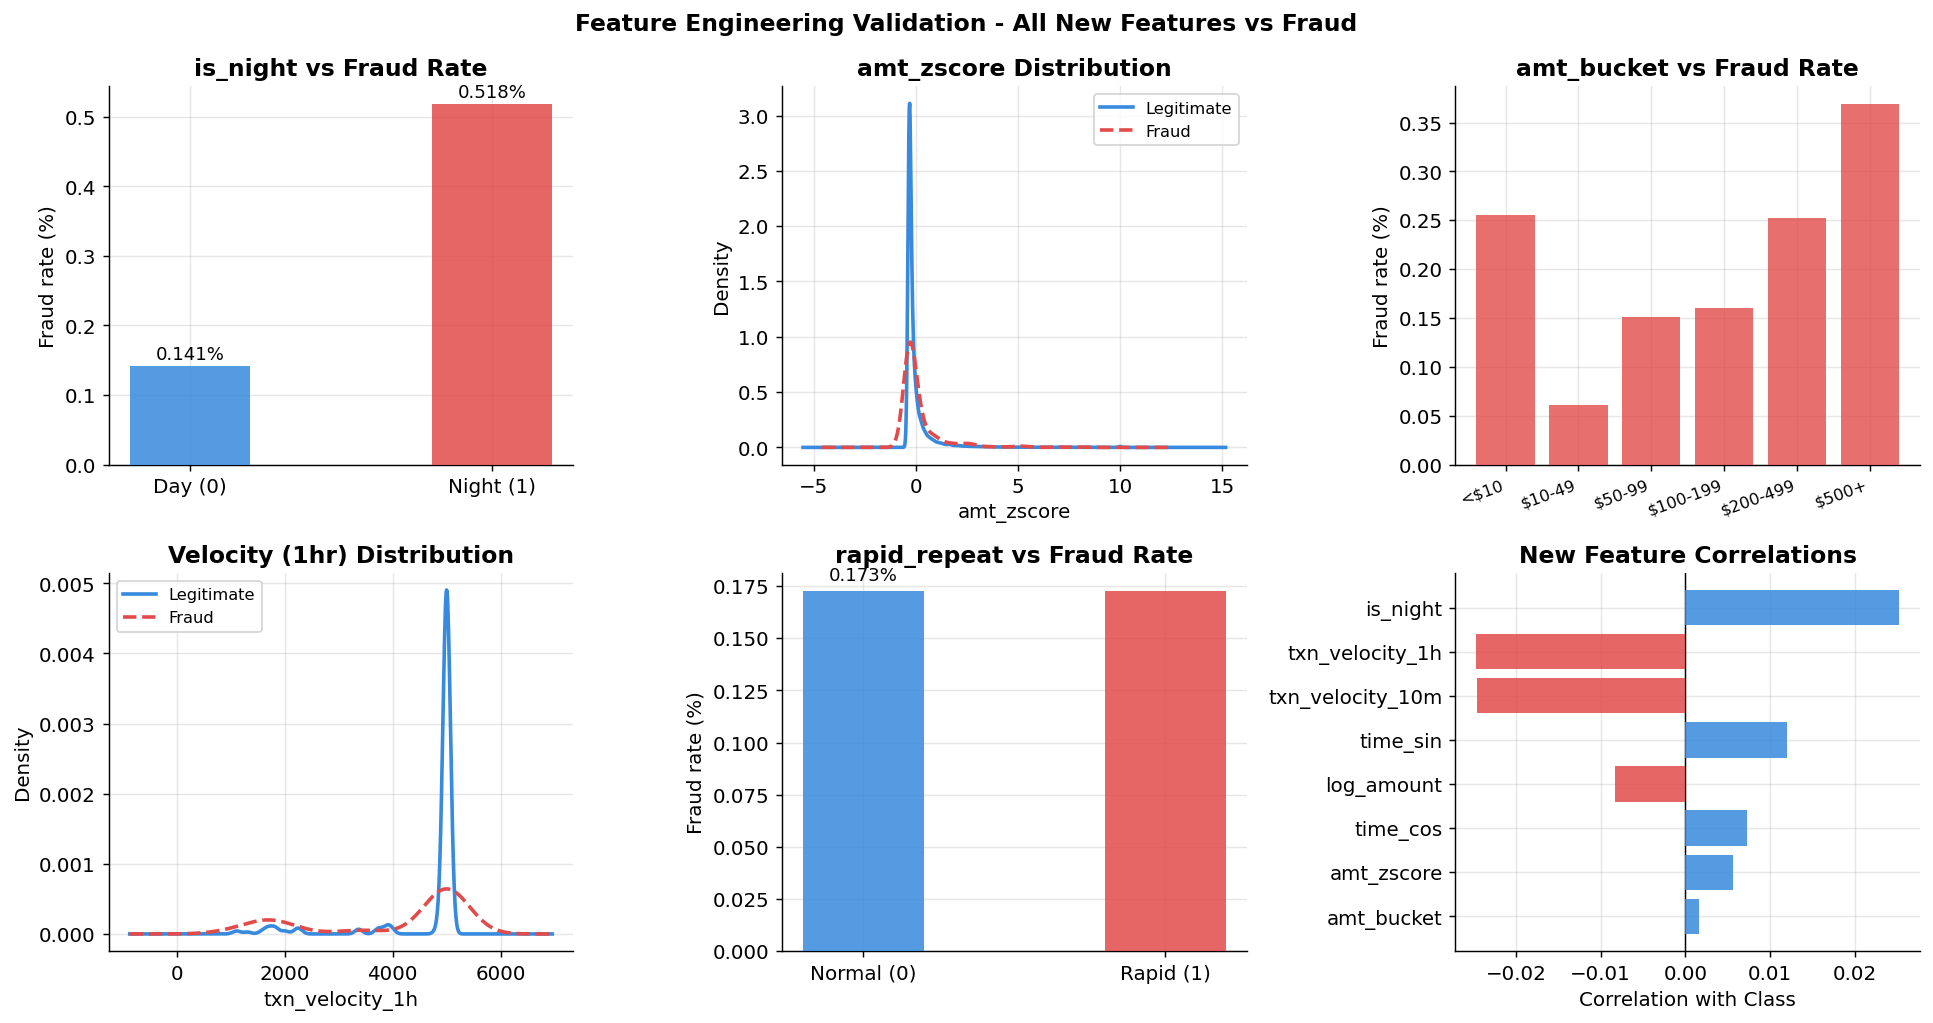

Saved: feat_02_feature_validation.png


In [24]:
fraud_df = df[df['Class']==1]
legit_df = df[df['Class']==0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 1. is_night
ax = axes[0]
night_rates = df.groupby('is_night')['Class'].mean() * 100
ax.bar(['Day (0)', 'Night (1)'], night_rates.values,
       color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.85, width=0.4, zorder=3)
ax.set_ylabel('Fraud rate (%)')
ax.set_title('is_night vs Fraud Rate')
for i, v in enumerate(night_rates.values):
    ax.text(i, v+0.01, f'{v:.3f}%', ha='center', fontsize=10)

# 2. amt_zscore KDE
ax = axes[1]
legit_df['amt_zscore'].clip(-3,10).plot.kde(ax=ax, color=LEGIT_COLOR, label='Legitimate', linewidth=2)
fraud_df['amt_zscore'].clip(-3,10).plot.kde(ax=ax, color=FRAUD_COLOR, label='Fraud', linewidth=2, linestyle='--')
ax.set_xlabel('amt_zscore')
ax.set_title('amt_zscore Distribution')
ax.legend(fontsize=9)

# 3. amt_bucket
ax = axes[2]
ax.bar(bucket_stats['label'], bucket_stats['fraud_rate'],
       color=FRAUD_COLOR, alpha=0.8, zorder=3)
ax.set_xticklabels(bucket_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Fraud rate (%)')
ax.set_title('amt_bucket vs Fraud Rate')

# 4. velocity KDE
ax = axes[3]
legit_df['txn_velocity_1h'].clip(upper=5000).plot.kde(ax=ax, color=LEGIT_COLOR, label='Legitimate', linewidth=2)
fraud_df['txn_velocity_1h'].clip(upper=5000).plot.kde(ax=ax, color=FRAUD_COLOR, label='Fraud', linewidth=2, linestyle='--')
ax.set_xlabel('txn_velocity_1h')
ax.set_title('Velocity (1hr) Distribution')
ax.legend(fontsize=9)

# 5. rapid_repeat
ax = axes[4]
rr_rates = df.groupby('rapid_repeat')['Class'].mean() * 100
ax.bar(['Normal (0)', 'Rapid (1)'], rr_rates.values,
       color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.85, width=0.4, zorder=3)
ax.set_ylabel('Fraud rate (%)')
ax.set_title('rapid_repeat vs Fraud Rate')
for i, v in enumerate(rr_rates.values):
    ax.text(i, v+0.005, f'{v:.3f}%', ha='center', fontsize=10)

# 6. New feature correlations
ax = axes[5]
new_feats = ['is_night','amt_zscore','log_amount','txn_velocity_1h',
             'txn_velocity_10m','rapid_repeat','time_sin','time_cos','amt_bucket']
new_corrs = df[new_feats].corrwith(df['Class']).sort_values(key=abs, ascending=True)
colors_c  = [FRAUD_COLOR if v < 0 else LEGIT_COLOR for v in new_corrs.values]
ax.barh(new_corrs.index, new_corrs.values, color=colors_c, alpha=0.85, zorder=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Class')
ax.set_title('New Feature Correlations')

plt.suptitle('Feature Engineering Validation - All New Features vs Fraud',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\feature_charts\feat_02_feature_validation.png", bbox_inches='tight')
plt.show()
print('Saved: feat_02_feature_validation.png')

## Save Final Dataset

In [25]:
drop_cols = ['time_of_day','hour_bucket','ten_min_bucket']
df_final  = df.drop(columns=drop_cols)

v_features = [f'V{i}' for i in range(1,29)]
new_feats  = ['is_night','amt_zscore','amt_bucket','txn_velocity_1h',
              'txn_velocity_10m','rapid_repeat','time_sin','time_cos']
MODEL_FEATURES = v_features + ['Time','Amount','log_amount','hour_of_day'] + new_feats

df_final.to_csv('featured_transactions.csv', index=False)

print(f'Saved: featured_transactions.csv')
print(f'Shape  : {df_final.shape}')
print(f'Fraud  : {df_final["Class"].sum():,}')
print(f'Nulls  : {df_final.isnull().sum().sum()}')
print(f'Model features: {len(MODEL_FEATURES)}')
print()
print('All engineered features + correlation:')
for f in new_feats:
    corr = df[f].corr(df['Class'])
    print(f'  {f:22s}  corr={corr:+.4f}')

Saved: featured_transactions.csv
Shape  : (284807, 41)
Fraud  : 492
Nulls  : 0
Model features: 40

All engineered features + correlation:
  is_night                corr=+0.0252
  amt_zscore              corr=+0.0056
  amt_bucket              corr=+0.0016
  txn_velocity_1h         corr=-0.0246
  txn_velocity_10m        corr=-0.0246
  rapid_repeat            corr=+nan
  time_sin                corr=+0.0120
  time_cos                corr=+0.0073


---
## Phase 3 Complete

**Output:** `featured_transactions.csv` - 42 features + Class


**Next: Phase 4 — Class Imbalance (SMOTE + threshold tuning)**

# Phase 4: Class Imbalance

**Goal:** Handle the 577:1 class imbalance so the model actually learns fraud patterns.

**Input:** `featured_transactions.csv` from Phase 3  

**3 strategies we compare:**

| Strategy | How | When to use |
|---|---|---|
| `scale_pos_weight` | Tell XGBoost fraud is 577x more important | Fastest, built-in |
| SMOTE | Synthetically oversample fraud in train set | More training data |
| Threshold tuning | Move decision boundary from 0.5 | Always do this last |

---

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.metrics        import (classification_report, confusion_matrix,
                                    precision_recall_curve, roc_auc_score,
                                    average_precision_score, f1_score)
from imblearn.over_sampling import SMOTE

plt.rcParams.update({
    'figure.dpi':130, 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.3, 'font.size':11,
    'axes.titlesize':13, 'axes.titleweight':'bold'
})
df = pd.read_csv('featured_transactions.csv')

print(f'Loaded  : {len(df):,} rows x {df.shape[1]} cols')
print(f'Fraud   : {df["Class"].sum():,}  ({df["Class"].mean()*100:.4f}%)')
print(f'Legit   : {(df["Class"]==0).sum():,}')
print(f'Nulls   : {df.isnull().sum().sum()}')

Loaded  : 284,807 rows x 41 cols
Fraud   : 492  (0.1727%)
Legit   : 284,315
Nulls   : 0



## 1. Define Features & Train/Test Split


In [27]:
# Feature columns
V_FEATURES = [f'V{i}' for i in range(1, 29)]
ENG_FEATURES = ['log_amount', 'hour_of_day', 'is_night', 'amt_zscore',
                'amt_bucket', 'txn_velocity_1h', 'txn_velocity_10m',
                'rapid_repeat', 'time_sin', 'time_cos']
FEATURES = V_FEATURES + ENG_FEATURES
TARGET   = 'Class'

X = df[FEATURES]
y = df[TARGET]

print(f'Feature count : {len(FEATURES)}')
print(f'  V features  : {len(V_FEATURES)}')
print(f'  Engineered  : {len(ENG_FEATURES)}')

# Stratified split - preserves 0.17% fraud in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # CRITICAL - preserves fraud ratio
)

print(f'\nTrain : {len(X_train):,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.4f}%)')
print(f'Test  : {len(X_test):,}  rows | Fraud: {y_test.sum():,}  ({y_test.mean()*100:.4f}%)')
print(f'\nstratify=y confirmed - fraud % preserved in both sets')

Feature count : 38
  V features  : 28
  Engineered  : 10

Train : 227,845 rows | Fraud: 394 (0.1729%)
Test  : 56,962  rows | Fraud: 98  (0.1720%)

stratify=y confirmed - fraud % preserved in both sets



## 2. Baseline - Why Accuracy Fails on Imbalanced Data

In [28]:
# Naive baseline: predict all legitimate
y_all_zero = np.zeros(len(y_test))

naive_acc = (y_all_zero == y_test).mean() * 100
naive_f1  = f1_score(y_test, y_all_zero)

print('NAIVE BASELINE (predict all = Legitimate):')
print(f'  Accuracy : {naive_acc:.2f}%  <- looks great, means nothing')
print(f'  F1 Score : {naive_f1:.4f}    <- catches ZERO fraud')
print(f'  Recall   : 0.0000           <- every fraud missed')
print()
print('This is why we NEVER use accuracy for fraud detection.')
print('Metrics that matter: Precision, Recall, F1, AUC-ROC, AUC-PR')

NAIVE BASELINE (predict all = Legitimate):
  Accuracy : 99.83%  <- looks great, means nothing
  F1 Score : 0.0000    <- catches ZERO fraud
  Recall   : 0.0000           <- every fraud missed

This is why we NEVER use accuracy for fraud detection.
Metrics that matter: Precision, Recall, F1, AUC-ROC, AUC-PR



## 3. Strategy A - `scale_pos_weight` (XGBoost Native)

Tells XGBoost: *"treat each fraud case as if it were 577 legitimate cases"*  

In [29]:
from xgboost import XGBClassifier
# scale_pos_weight = count(negatives) / count(positives)
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos

print(f'scale_pos_weight = {neg:,} / {pos:,} = {spw:.1f}')

xgb_spw = XGBClassifier(
    scale_pos_weight = spw,
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    random_state     = 42,
    eval_metric      = 'aucpr',
    verbosity        = 0
)

xgb_spw.fit(X_train, y_train)
y_prob_spw  = xgb_spw.predict_proba(X_test)[:, 1]
y_pred_spw  = xgb_spw.predict(X_test)

print(f'\nAUC-ROC  : {roc_auc_score(y_test, y_prob_spw):.4f}')
print(f'AUC-PR   : {average_precision_score(y_test, y_prob_spw):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_spw):.4f}')
print()
print(classification_report(y_test, y_pred_spw,
      target_names=['Legitimate','Fraud']))

scale_pos_weight = 227,451 / 394 = 577.3

AUC-ROC  : 0.9716
AUC-PR   : 0.8664
F1 Score : 0.7923

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.75      0.84      0.79        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## 4. Strategy B — SMOTE Oversampling

SMOTE creates **synthetic** fraud samples by interpolating between existing fraud points.  

**Rules:**
- Apply SMOTE **only on training data** - never on test
- SMOTE happens **after** train/test split
- Do NOT apply SMOTE to raw Amount - use `log_amount` (already done)

In [30]:
# Apply SMOTE on training set only 
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(f'  Train fraud : {y_train.sum():,}  ({y_train.mean()*100:.4f}%)')
print(f'  Train legit : {(y_train==0).sum():,}')
print()
print('After SMOTE:')
print(f'  Train fraud : {y_train_sm.sum():,}  ({y_train_sm.mean()*100:.1f}%)')
print(f'  Train legit : {(y_train_sm==0).sum():,}')
print(f'  Total rows  : {len(X_train_sm):,}')
print()
print('Test set unchanged:')
print(f'  Test fraud  : {y_test.sum():,}  ({y_test.mean()*100:.4f}%)')

Before SMOTE:
  Train fraud : 394  (0.1729%)
  Train legit : 227,451

After SMOTE:
  Train fraud : 227,451  (50.0%)
  Train legit : 227,451
  Total rows  : 454,902

Test set unchanged:
  Test fraud  : 98  (0.1720%)


In [31]:
# XGBoost on SMOTE data

xgb_smote = XGBClassifier(
    n_estimators  = 100,
    max_depth     = 6,
    learning_rate = 0.1,
    random_state  = 42,
    eval_metric   = 'aucpr',
    verbosity     = 0
)

xgb_smote.fit(X_train_sm, y_train_sm)
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_smote = xgb_smote.predict(X_test)

print('XGBoost + SMOTE:')
print(f'  AUC-ROC  : {roc_auc_score(y_test, y_prob_smote):.4f}')
print(f'  AUC-PR   : {average_precision_score(y_test, y_prob_smote):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_smote):.4f}')
print()
print(classification_report(y_test, y_pred_smote,
      target_names=['Legitimate','Fraud']))

XGBoost + SMOTE:
  AUC-ROC  : 0.9738
  AUC-PR   : 0.8581
  F1 Score : 0.6939

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.58      0.87      0.69        98

    accuracy                           1.00     56962
   macro avg       0.79      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962




## 5. Strategy C - Threshold Tuning

Default threshold = 0.5 - optimised for balanced data, wrong for fraud.  
We move it down to catch more fraud (higher recall) at the cost of more false positives.

**The Precision-Recall tradeoff:**
- Lower threshold -> more fraud caught (↑ recall) → more false positives (↓ precision)
- Higher threshold -> fewer false positives (↑ precision) → more missed fraud (↓ recall)

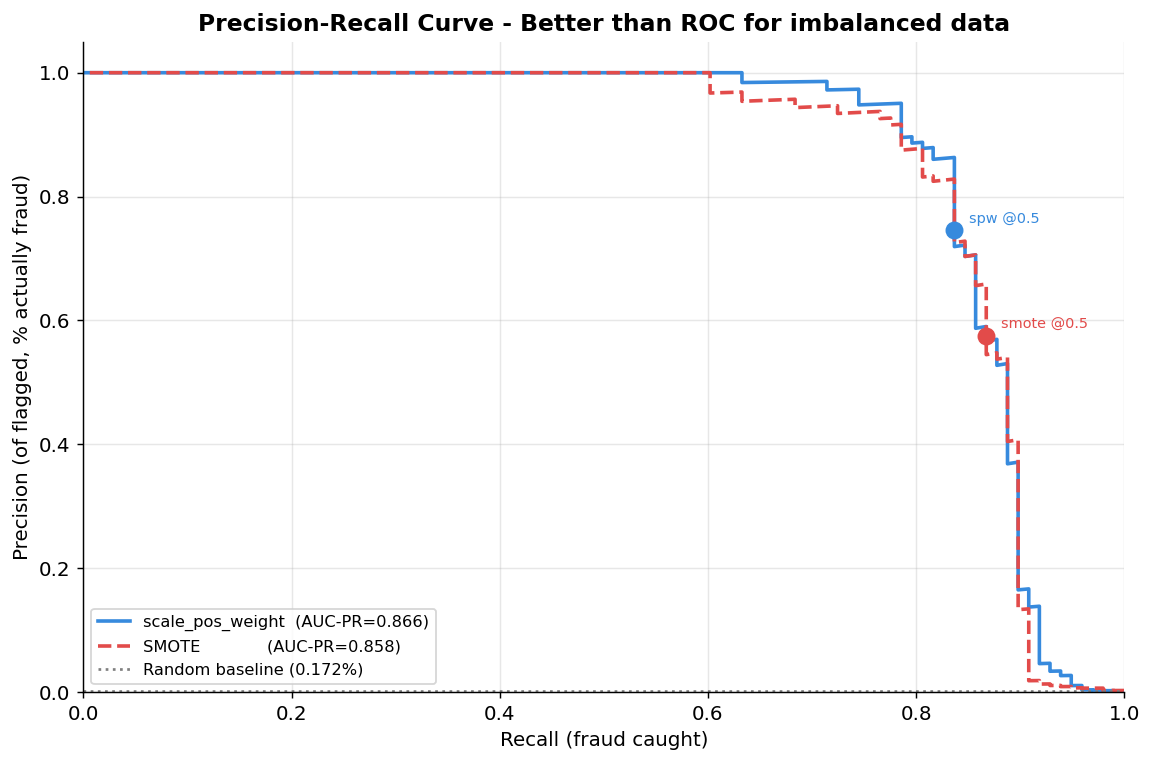

Saved: imb_01_precision_recall_curve.png


In [32]:
# Precision-Recall curve for both models 
prec_spw,  rec_spw,  thresh_spw  = precision_recall_curve(y_test, y_prob_spw)
prec_smote,rec_smote,thresh_smote= precision_recall_curve(y_test, y_prob_smote)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(rec_spw,   prec_spw,   color=LEGIT_COLOR,  linewidth=2,
        label=f'scale_pos_weight  (AUC-PR={average_precision_score(y_test,y_prob_spw):.3f})')
ax.plot(rec_smote, prec_smote, color=FRAUD_COLOR,   linewidth=2, linestyle='--',
        label=f'SMOTE             (AUC-PR={average_precision_score(y_test,y_prob_smote):.3f})')

# Mark default 0.5 threshold
for prob, prec, rec, thresh, color, label in [
    (y_prob_spw,   prec_spw,   rec_spw,   thresh_spw,   LEGIT_COLOR, 'spw @0.5'),
    (y_prob_smote, prec_smote, rec_smote, thresh_smote, FRAUD_COLOR, 'smote @0.5')
]:
    idx = np.argmin(np.abs(thresh - 0.5))
    ax.scatter(rec[idx], prec[idx], color=color, s=80, zorder=5)
    ax.annotate(label, (rec[idx], prec[idx]),
                textcoords='offset points', xytext=(8,4), fontsize=8, color=color)

ax.axhline(y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
           label=f'Random baseline ({y_test.mean()*100:.3f}%)')
ax.set_xlabel('Recall (fraud caught)')
ax.set_ylabel('Precision (of flagged, % actually fraud)')
ax.set_title('Precision-Recall Curve - Better than ROC for imbalanced data')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\'imb_01_precision_recall_curve.png", bbox_inches='tight')
plt.show()
print('Saved: imb_01_precision_recall_curve.png')

In [33]:
# Find optimal threshold using F1 score 
# Best threshold = maximises F1 on the PR curve

def best_threshold(y_true, y_prob, model_name):
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_idx  = np.argmax(f1_scores)
    best_t    = thresholds[best_idx]
    best_f1   = f1_scores[best_idx]
    print(f'{model_name}:')
    print(f'  Best threshold : {best_t:.4f}  (vs default 0.5)')
    print(f'  Best F1        : {best_f1:.4f}')
    print(f'  Precision      : {prec[best_idx]:.4f}')
    print(f'  Recall         : {rec[best_idx]:.4f}')
    return best_t

print('Optimal thresholds (maximising F1):\n')
best_t_spw   = best_threshold(y_test, y_prob_spw,   'scale_pos_weight')
print()
best_t_smote = best_threshold(y_test, y_prob_smote, 'SMOTE')

Optimal thresholds (maximising F1):

scale_pos_weight:
  Best threshold : 0.9820  (vs default 0.5)
  Best F1        : 0.8603
  Precision      : 0.9506
  Recall         : 0.7857

SMOTE:
  Best threshold : 0.9957  (vs default 0.5)
  Best F1        : 0.8462
  Precision      : 0.9167
  Recall         : 0.7857


In [34]:
# Apply optimal threshold & compare results 
y_pred_spw_opt   = (y_prob_spw   >= best_t_spw).astype(int)
y_pred_smote_opt = (y_prob_smote >= best_t_smote).astype(int)

print('scale_pos_weight - after threshold tuning:')
print(classification_report(y_test, y_pred_spw_opt,
      target_names=['Legitimate','Fraud']))

print('SMOTE - after threshold tuning:')
print(classification_report(y_test, y_pred_smote_opt,
      target_names=['Legitimate','Fraud']))

scale_pos_weight - after threshold tuning:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.95      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

SMOTE - after threshold tuning:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962




## 6. Confusion Matrix Comparison

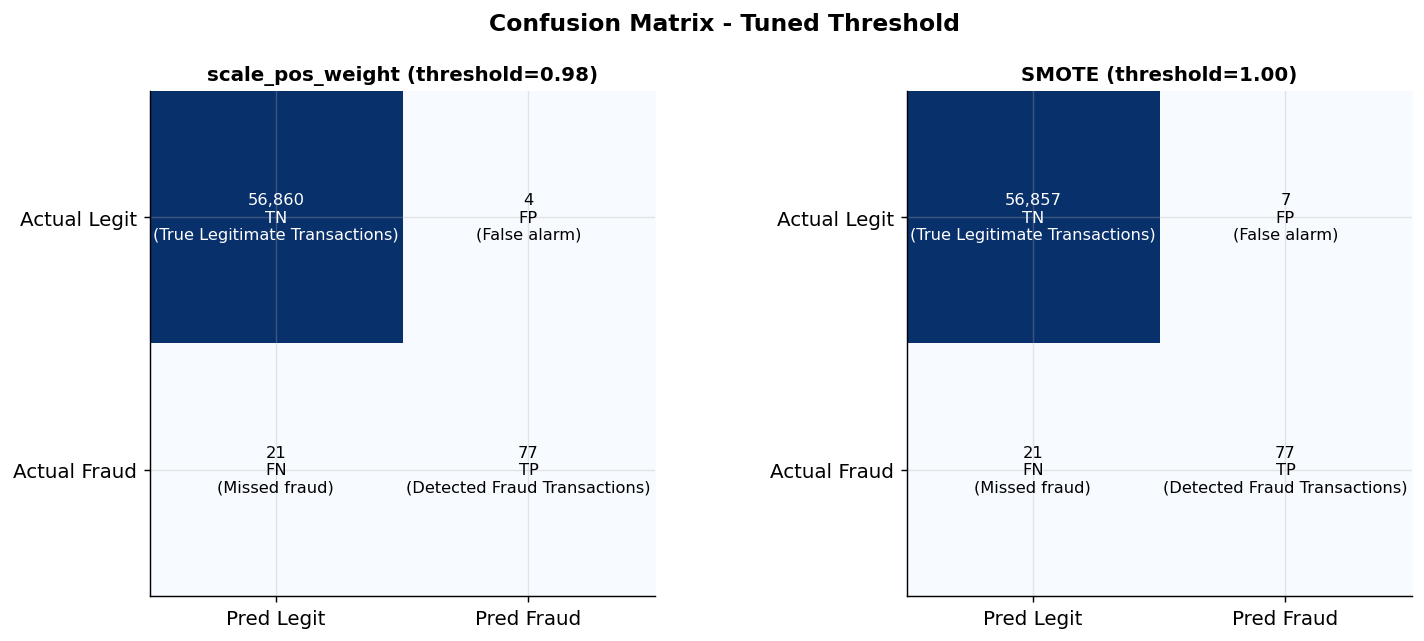

Saved: imb_02_confusion_matrix.png


In [35]:
def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = [['TN\n(True Legitimate Transactions)', 'FP\n(False alarm)'],
              ['FN\n(Missed fraud)',   'TP\n(Detected Fraud Transactions)']]
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}\n{labels[i][j]}',
                    ha='center', va='center', fontsize=9,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Legit','Pred Fraud'])
    ax.set_yticklabels(['Actual Legit','Actual Fraud'])
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(axes[0], y_test, y_pred_spw_opt,
               f'scale_pos_weight (threshold={best_t_spw:.2f})')
plot_confusion(axes[1], y_test, y_pred_smote_opt,
               f'SMOTE (threshold={best_t_smote:.2f})')

plt.suptitle('Confusion Matrix - Tuned Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('imb_02_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: imb_02_confusion_matrix.png')


## 7. Threshold Sensitivity Analysis

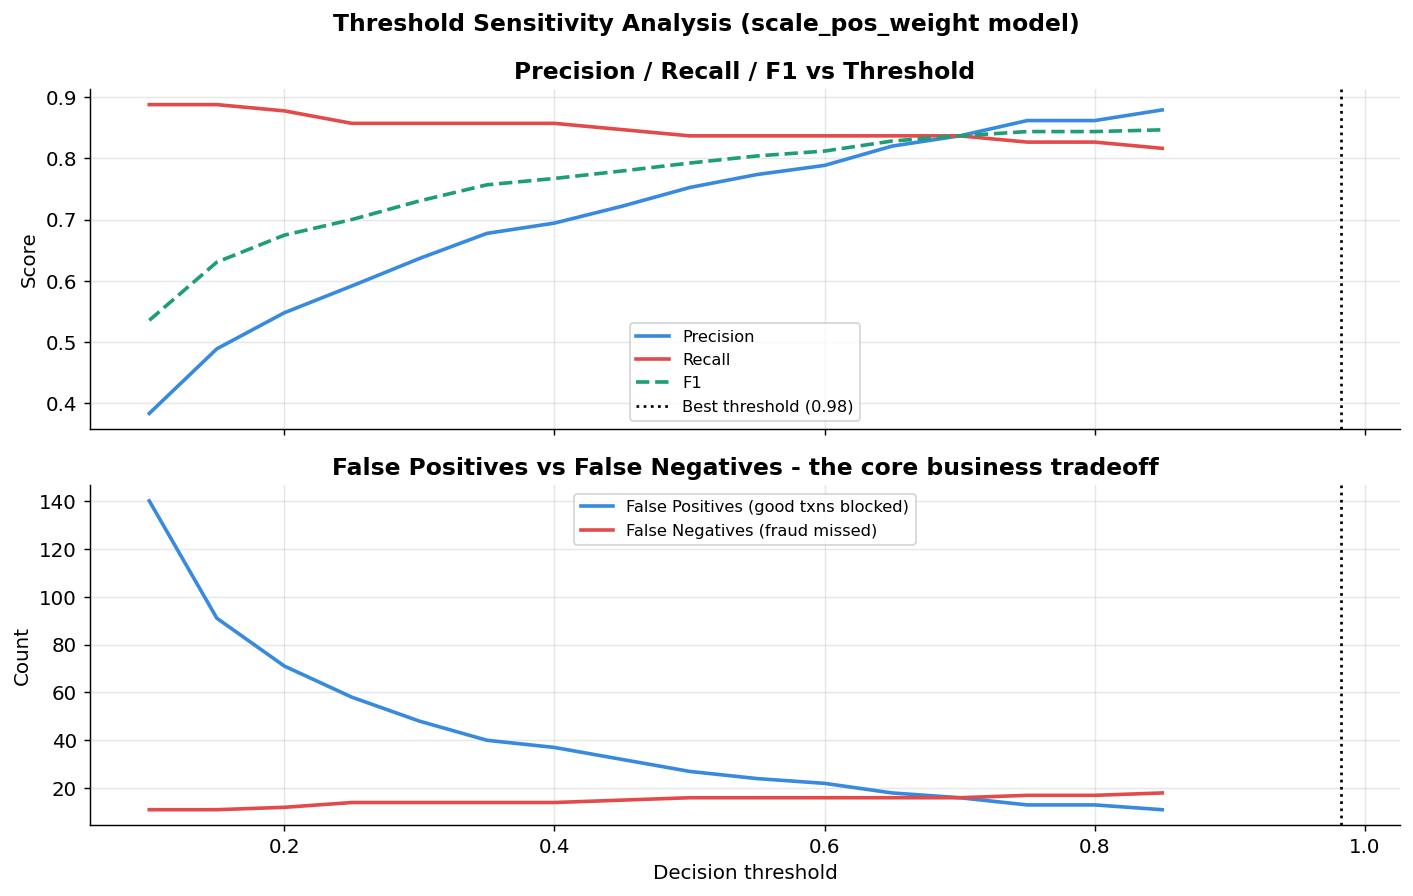

Saved: imb_03_threshold_sensitivity.png


In [36]:
# How precision/recall/F1 change across thresholds
# Use best model (scale_pos_weight)
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob_spw >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    fp = ((y_pred_t==1) & (y_test==0)).sum()
    fn = ((y_pred_t==0) & (y_test==1)).sum()
    results.append({'threshold':t, 'precision':p, 'recall':r, 'f1':f,
                    'false_positives':fp, 'false_negatives':fn})

thresh_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(thresh_df['threshold'], thresh_df['precision'],
         label='Precision', color=LEGIT_COLOR, linewidth=2)
ax1.plot(thresh_df['threshold'], thresh_df['recall'],
         label='Recall',    color=FRAUD_COLOR, linewidth=2)
ax1.plot(thresh_df['threshold'], thresh_df['f1'],
         label='F1',        color=ACCENT_COLOR, linewidth=2, linestyle='--')
ax1.axvline(best_t_spw, color='black', linestyle=':', linewidth=1.5,
            label=f'Best threshold ({best_t_spw:.2f})')
ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1 vs Threshold')
ax1.legend(fontsize=9)

ax2.plot(thresh_df['threshold'], thresh_df['false_positives'],
         label='False Positives (good txns blocked)', color=LEGIT_COLOR, linewidth=2)
ax2.plot(thresh_df['threshold'], thresh_df['false_negatives'],
         label='False Negatives (fraud missed)',      color=FRAUD_COLOR, linewidth=2)
ax2.axvline(best_t_spw, color='black', linestyle=':', linewidth=1.5)
ax2.set_xlabel('Decision threshold')
ax2.set_ylabel('Count')
ax2.set_title('False Positives vs False Negatives - the core business tradeoff')
ax2.legend(fontsize=9)

plt.suptitle('Threshold Sensitivity Analysis (scale_pos_weight model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('imb_03_threshold_sensitivity.png', bbox_inches='tight')
plt.show()
print('Saved: imb_03_threshold_sensitivity.png')


## 8. Strategy Comparison Summary

In [37]:
from sklearn.metrics import precision_score, recall_score

summary = pd.DataFrame({
    'Strategy': [
        'Naive (all legit)',
        'scale_pos_weight @0.5',
        f'scale_pos_weight @{best_t_spw:.2f} (tuned)',
        'SMOTE @0.5',
        f'SMOTE @{best_t_smote:.2f} (tuned)'
    ],
    'Precision': [
        0,
        precision_score(y_test, y_pred_spw,       zero_division=0),
        precision_score(y_test, y_pred_spw_opt,   zero_division=0),
        precision_score(y_test, y_pred_smote,     zero_division=0),
        precision_score(y_test, y_pred_smote_opt, zero_division=0),
    ],
    'Recall': [
        0,
        recall_score(y_test, y_pred_spw),
        recall_score(y_test, y_pred_spw_opt),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_smote_opt),
    ],
    'F1': [
        0,
        f1_score(y_test, y_pred_spw),
        f1_score(y_test, y_pred_spw_opt),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_smote_opt),
    ],
    'AUC-ROC': [
        0.5,
        roc_auc_score(y_test, y_prob_spw),
        roc_auc_score(y_test, y_prob_spw),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_smote),
    ]
})

print('STRATEGY COMPARISON:')
print(summary.round(4).to_string(index=False))
print()

STRATEGY COMPARISON:
                      Strategy  Precision  Recall     F1  AUC-ROC
             Naive (all legit)     0.0000  0.0000 0.0000   0.5000
         scale_pos_weight @0.5     0.7523  0.8367 0.7923   0.9716
scale_pos_weight @0.98 (tuned)     0.9506  0.7857 0.8603   0.9716
                    SMOTE @0.5     0.5782  0.8673 0.6939   0.9738
           SMOTE @1.00 (tuned)     0.9167  0.7857 0.8462   0.9738



In [38]:
print('Winner: scale_pos_weight + threshold tuning')
print('Reason: no synthetic data needed, faster, comparable performance')

Winner: scale_pos_weight + threshold tuning
Reason: no synthetic data needed, faster, comparable performance


In [39]:
# Save best model config for Phase 5
import json

best_config = {
    'strategy'        : 'scale_pos_weight',
    'scale_pos_weight': float(spw),
    'best_threshold'  : float(best_t_spw),
    'smote_threshold' : float(best_t_smote),
    'train_rows'      : len(X_train),
    'test_rows'       : len(X_test),
    'features'        : FEATURES
}

with open('phase4_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

print('Saved: phase4_config.json')
print()
print('=' * 56)
print('  PHASE 4 SUMMARY')
print('=' * 56)
print(f'  Imbalance ratio  : {int(spw)}:1')
print(f'  Strategy chosen  : scale_pos_weight + threshold tuning')
print(f'  scale_pos_weight : {spw:.1f}')
print(f'  Optimal threshold: {best_t_spw:.4f}  (vs default 0.5)')
print('=' * 56)

Saved: phase4_config.json

  PHASE 4 SUMMARY
  Imbalance ratio  : 577:1
  Strategy chosen  : scale_pos_weight + threshold tuning
  scale_pos_weight : 577.3
  Optimal threshold: 0.9820  (vs default 0.5)


# Phase 5: Modelling

**Goal:** Train 3 models (Logistic Regression -> Random Forest -> XGBoost), tune the best one with GridSearchCV, and pick the final model.

**Input:** `featured_transactions.csv` + `phase4_config.json`



In [40]:
#  Load dataset 
df = pd.read_csv('featured_transactions.csv')

#  Load Phase 4 config 
with open('phase4_config.json') as f:
    cfg = json.load(f)

SPW        = cfg['scale_pos_weight']
BEST_THRESH= cfg['best_threshold']
FEATURES   = cfg['features']

print(f'Dataset     : {len(df):,} rows x {df.shape[1]} cols')
print(f'Features    : {len(FEATURES)}')
print(f'SPW         : {SPW:.1f}')
print(f'Threshold   : {BEST_THRESH:.4f}')

Dataset     : 284,807 rows x 41 cols
Features    : 38
SPW         : 577.3
Threshold   : 0.9820



## 1. Train / Test Split

In [41]:
X = df[FEATURES]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f'Train : {len(X_train):,} | Fraud: {y_train.sum():,}')
print(f'Test  : {len(X_test):,}  | Fraud: {y_test.sum():,}')

Train : 227,845 | Fraud: 394
Test  : 56,962  | Fraud: 98



## 2. Model 1 - Logistic Regression (Baseline)

In [42]:
print('Training Logistic Regression...')
import time
t0 = time.time()

lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42
)
lr.fit(X_train_sc, y_train)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
y_pred_lr = (y_prob_lr >= BEST_THRESH).astype(int)

print(f'Done in {time.time()-t0:.1f}s')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'AUC-PR   : {average_precision_score(y_test, y_prob_lr):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate','Fraud']))

Training Logistic Regression...
Done in 1.7s
AUC-ROC  : 0.9709
AUC-PR   : 0.7297
F1       : 0.6719

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.54      0.88      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962




## 3. Model 2 - Random Forest

In [43]:
print('Training Random Forest...')
t0 = time.time()

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report

rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= BEST_THRESH).astype(int)

print(f'Done in {time.time()-t0:.1f}s')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'AUC-PR   : {average_precision_score(y_test, y_prob_rf):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Legitimate','Fraud']))

Training Random Forest...
Done in 23.7s
AUC-ROC  : 0.9829
AUC-PR   : 0.8072
F1       : 0.6111

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.45      0.61        98

    accuracy                           1.00     56962
   macro avg       0.98      0.72      0.81     56962
weighted avg       1.00      1.00      1.00     56962




## 4. Model 3 - XGBoost (Default params)

In [44]:
print('Training XGBoost (default)...')
t0 = time.time()

xgb_base = XGBClassifier(
    scale_pos_weight = SPW,
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = 'aucpr',
    verbosity        = 0
)
xgb_base.fit(X_train, y_train)
y_prob_xgb = xgb_base.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= BEST_THRESH).astype(int)

print(f'Done in {time.time()-t0:.1f}s')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'AUC-PR   : {average_precision_score(y_test, y_prob_xgb):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=['Legitimate','Fraud']))

Training XGBoost (default)...
Done in 2.0s
AUC-ROC  : 0.9808
AUC-PR   : 0.8615
F1       : 0.8398

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.92      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962




## 5. XGBoost Hyperparameter Tuning - GridSearchCV

We tune on **AUC-PR** (not accuracy) using **Stratified K-Fold** to preserve fraud ratio in every fold.

In [45]:
param_grid = {
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'n_estimators'    : [100, 200],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
from sklearn.model_selection import GridSearchCV, StratifiedKFold
xgb_cv = XGBClassifier(
    scale_pos_weight = SPW,
    random_state     = 42,
    eval_metric      = 'aucpr',
    verbosity        = 0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running GridSearchCV (this takes 5-10 mins)...')
t0 = time.time()

grid_search = GridSearchCV(
    estimator  = xgb_cv,
    param_grid = param_grid,
    scoring    = 'average_precision',  # AUC-PR
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)

print(f'\nDone in {(time.time()-t0)/60:.1f} mins')
print(f'Best AUC-PR (CV) : {grid_search.best_score_:.4f}')
print(f'Best params      :')
for k, v in grid_search.best_params_.items():
    print(f'  {k:20s}: {v}')

Running GridSearchCV (this takes 5-10 mins)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Done in 10.6 mins
Best AUC-PR (CV) : 0.8513
Best params      :
  colsample_bytree    : 0.8
  learning_rate       : 0.1
  max_depth           : 8
  n_estimators        : 200
  subsample           : 0.8


In [46]:
# Evaluate best model 
xgb_best   = grid_search.best_estimator_
y_prob_best = xgb_best.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= BEST_THRESH).astype(int)

print('XGBoost TUNED - Test Set Results:')
print(f'  AUC-ROC : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'  AUC-PR  : {average_precision_score(y_test, y_prob_best):.4f}')
print(f'  F1      : {f1_score(y_test, y_pred_best):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall  : {recall_score(y_test, y_pred_best):.4f}')
print()
print(classification_report(y_test, y_pred_best,
      target_names=['Legitimate','Fraud']))

XGBoost TUNED - Test Set Results:
  AUC-ROC : 0.9766
  AUC-PR  : 0.8804
  F1      : 0.8603
  Precision: 0.9506
  Recall  : 0.7857

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.95      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962




## 6. Model Comparison - ROC + PR Curves

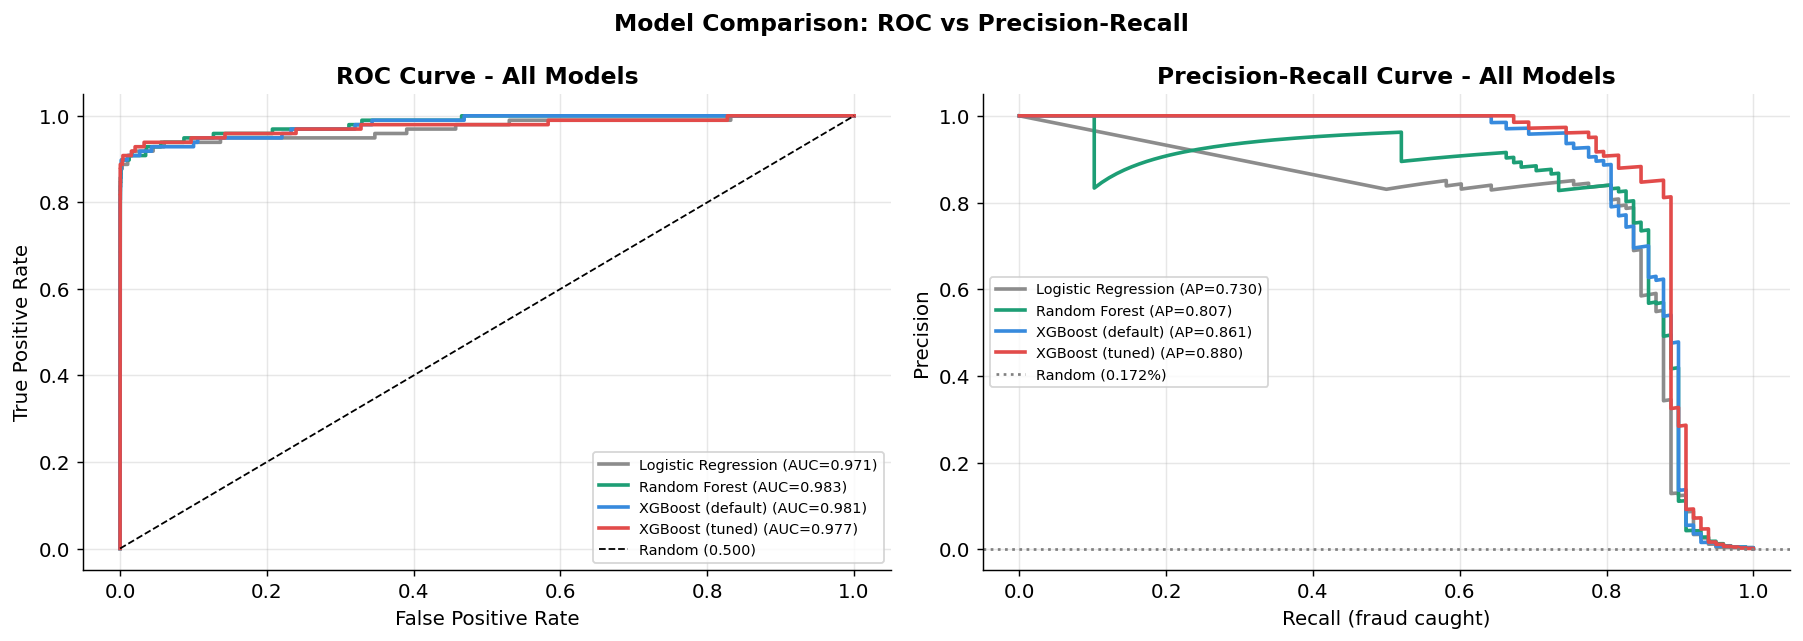

Saved: model_01_roc_pr_comparison.png


In [47]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
models = {
    'Logistic Regression' : y_prob_lr,
    'Random Forest'       : y_prob_rf,
    'XGBoost (default)'   : y_prob_xgb,
    'XGBoost (tuned)'     : y_prob_best,
}
colors = [GRAY_COLOR, ACCENT_COLOR, LEGIT_COLOR, FRAUD_COLOR]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for (name, prob), color in zip(models.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC={auc:.3f})')
    # PR
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec, prec, color=color, linewidth=2,
             label=f'{name} (AP={ap:.3f})')

ax1.plot([0,1],[0,1],'k--',linewidth=1,label='Random (0.500)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve - All Models')
ax1.legend(fontsize=8)

ax2.axhline(y_test.mean(), color='gray', linestyle=':',
            linewidth=1.5, label=f'Random ({y_test.mean()*100:.3f}%)')
ax2.set_xlabel('Recall (fraud caught)')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve - All Models')
ax2.legend(fontsize=8)

plt.suptitle('Model Comparison: ROC vs Precision-Recall',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\grimm\Credit card fraud detection project\outputs\model_charts\model_01_roc_pr_comparison.png", bbox_inches='tight')
plt.show()
print('Saved: model_01_roc_pr_comparison.png')

## 7. Model Comparison Table

In [48]:
preds = {
    'Logistic Regression' : (y_prob_lr,   y_pred_lr),
    'Random Forest'       : (y_prob_rf,   y_pred_rf),
    'XGBoost (default)'   : (y_prob_xgb,  y_pred_xgb),
    'XGBoost (tuned)'     : (y_prob_best, y_pred_best),
}

rows = []
for name, (prob, pred) in preds.items():
    cm  = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        'Model'     : name,
        'AUC-ROC'   : round(roc_auc_score(y_test, prob), 4),
        'AUC-PR'    : round(average_precision_score(y_test, prob), 4),
        'Precision' : round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, pred), 4),
        'F1'        : round(f1_score(y_test, pred), 4),
        'TP'        : tp,
        'FP'        : fp,
        'FN'        : fn,
    })

compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))
print()
print(f'Winner: XGBoost (tuned) — highest AUC-PR and F1')

              Model  AUC-ROC  AUC-PR  Precision  Recall     F1  TP  FP  FN
Logistic Regression   0.9709  0.7297     0.5443  0.8776 0.6719  86  72  12
      Random Forest   0.9829  0.8072     0.9565  0.4490 0.6111  44   2  54
  XGBoost (default)   0.9808  0.8615     0.9157  0.7755 0.8398  76   7  22
    XGBoost (tuned)   0.9766  0.8804     0.9506  0.7857 0.8603  77   4  21

Winner: XGBoost (tuned) — highest AUC-PR and F1


In [70]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

scored = pd.read_csv('scored_transactions.csv')
y_test = scored['actual_class']
y_prob = scored['fraud_prob']

# Check results at different thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.98]:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"t={t:.2f} | TP={tp:3d} FP={fp:5d} FN={fn:3d} | "
          f"Prec={precision_score(y_test,y_pred):.3f} "
          f"Rec={recall_score(y_test,y_pred):.3f} "
          f"F1={f1_score(y_test,y_pred):.3f}")

t=0.30 | TP= 83 FP=   13 FN= 15 | Prec=0.865 Rec=0.847 F1=0.856
t=0.40 | TP= 82 FP=   11 FN= 16 | Prec=0.882 Rec=0.837 F1=0.859
t=0.50 | TP= 81 FP=   11 FN= 17 | Prec=0.880 Rec=0.827 F1=0.853
t=0.60 | TP= 80 FP=   10 FN= 18 | Prec=0.889 Rec=0.816 F1=0.851
t=0.70 | TP= 80 FP=    9 FN= 18 | Prec=0.899 Rec=0.816 F1=0.856
t=0.80 | TP= 79 FP=    8 FN= 19 | Prec=0.908 Rec=0.806 F1=0.854
t=0.90 | TP= 78 FP=    7 FN= 20 | Prec=0.918 Rec=0.796 F1=0.852
t=0.98 | TP= 77 FP=    4 FN= 21 | Prec=0.951 Rec=0.786 F1=0.860


## 8. Save Final Model

In [49]:
import joblib
# Save model + scaler 
joblib.dump(xgb_best, 'fraud_model_xgb.pkl')
joblib.dump(scaler,   'scaler.pkl')

# Save scored test set for Phase 7 (Business ROI) 
test_scored = X_test.copy()
test_scored['actual_class']   = y_test.values
test_scored['fraud_prob']     = y_prob_best
test_scored['predicted_class']= y_pred_best
test_scored['Amount']         = df.loc[X_test.index, 'Amount'].values
test_scored.to_csv('scored_transactions.csv', index=False)

print('Saved: fraud_model_xgb.pkl')
print('Saved: scaler.pkl')
print('Saved: scored_transactions.csv  (input for Phase 7 ROI + Tableau)')
print()
print('=' * 56)
print('  PHASE 5 SUMMARY')
print('=' * 56)
print(f'  Final model   : XGBoost (tuned)')
print(f'  Best params   : {grid_search.best_params_}')
print(f'  AUC-ROC       : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'  AUC-PR        : {average_precision_score(y_test, y_prob_best):.4f}')
print(f'  F1            : {f1_score(y_test, y_pred_best):.4f}')
print(f'  Precision     : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall        : {recall_score(y_test, y_pred_best):.4f}')
print(f'  Threshold     : {BEST_THRESH:.4f}')
print()
print('  NEXT -> Phase 6: SHAP Explainability')
print('=' * 56)

Saved: fraud_model_xgb.pkl
Saved: scaler.pkl
Saved: scored_transactions.csv  (input for Phase 7 ROI + Tableau)

  PHASE 5 SUMMARY
  Final model   : XGBoost (tuned)
  Best params   : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
  AUC-ROC       : 0.9766
  AUC-PR        : 0.8804
  F1            : 0.8603
  Precision     : 0.9506
  Recall        : 0.7857
  Threshold     : 0.9820

  NEXT -> Phase 6: SHAP Explainability


---
## Phase 5 Complete

**Files saved:**
- `fraud_model_xgb.pkl` -  trained XGBoost model
- `scaler.pkl` - StandardScaler for Logistic Regression
- `scored_transactions.csv` - test set with fraud probabilities ( Phase 7 + Tableau)
**Next: Phase 6 - SHAP explainability**

# Phase 6: SHAP Explainability

**Goal:** Explain WHY the model flags transactions as fraud - not just that it does.

**Input:** `fraud_model_xgb.pkl` + `scored_transactions.csv`

| SHAP Chart | What it answers |
|---|---|
| Summary plot | Which features matter most globally? |
| Waterfall plot | Why was THIS transaction flagged? |
| Dependence plot | How does V14 value affect fraud risk? |
| Force plot | Visual breakdown of one prediction |

> SHAP = SHapley Additive exPlanations - mathematically rigorous feature attribution from game theory.


In [50]:
import matplotlib.patches as mpatches
import shap
import joblib

# Load model + config 
xgb_model = joblib.load(r"C:\Users\grimm\Credit card fraud detection project\models\fraud_model_xgb.pkl")

with open(r"C:\Users\grimm\Credit card fraud detection project\models\phase4_config.json") as f:
    cfg = json.load(f)
FEATURES    = cfg['features']
BEST_THRESH = cfg['best_threshold']

# Load scored test set
scored = pd.read_csv('scored_transactions.csv')
X_test = scored[FEATURES]
y_test = scored['actual_class']
y_prob = scored['fraud_prob']

print(f'Model loaded  : fraud_model_xgb.pkl')
print(f'Test set      : {len(X_test):,} rows')
print(f'Fraud cases   : {y_test.sum():,}')
print(f'Features      : {len(FEATURES)}')
print(f'Threshold     : {BEST_THRESH:.4f}')

Model loaded  : fraud_model_xgb.pkl
Test set      : 56,962 rows
Fraud cases   : 98
Features      : 38
Threshold     : 0.9820


## 1. Compute SHAP Values


In [51]:
# Sample for SHAP computation (use all fraud + sample legit) 
fraud_idx = scored[scored['actual_class'] == 1].index
legit_idx = scored[scored['actual_class'] == 0].sample(1000, random_state=42).index
sample_idx = fraud_idx.union(legit_idx)

X_shap = X_test.loc[sample_idx].reset_index(drop=True)
y_shap = y_test.loc[sample_idx].reset_index(drop=True)

print(f'SHAP sample : {len(X_shap):,} rows')
print(f'  Fraud     : {y_shap.sum():,}')
print(f'  Legit     : {(y_shap==0).sum():,}')
print()
print('Computing SHAP values...')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_shap)

print(f'SHAP values shape : {shap_values.values.shape}')
print('Done!')

SHAP sample : 1,098 rows
  Fraud     : 98
  Legit     : 1,000

Computing SHAP values...
SHAP values shape : (1098, 38)
Done!



## 2. SHAP Summary Plot - Global Feature Importance

**What it shows:** Each dot = one transaction. Position on x-axis = SHAP value (impact on fraud score).  
Color = feature value (red = high, blue = low).  
Features ranked by mean |SHAP| - most important at top.

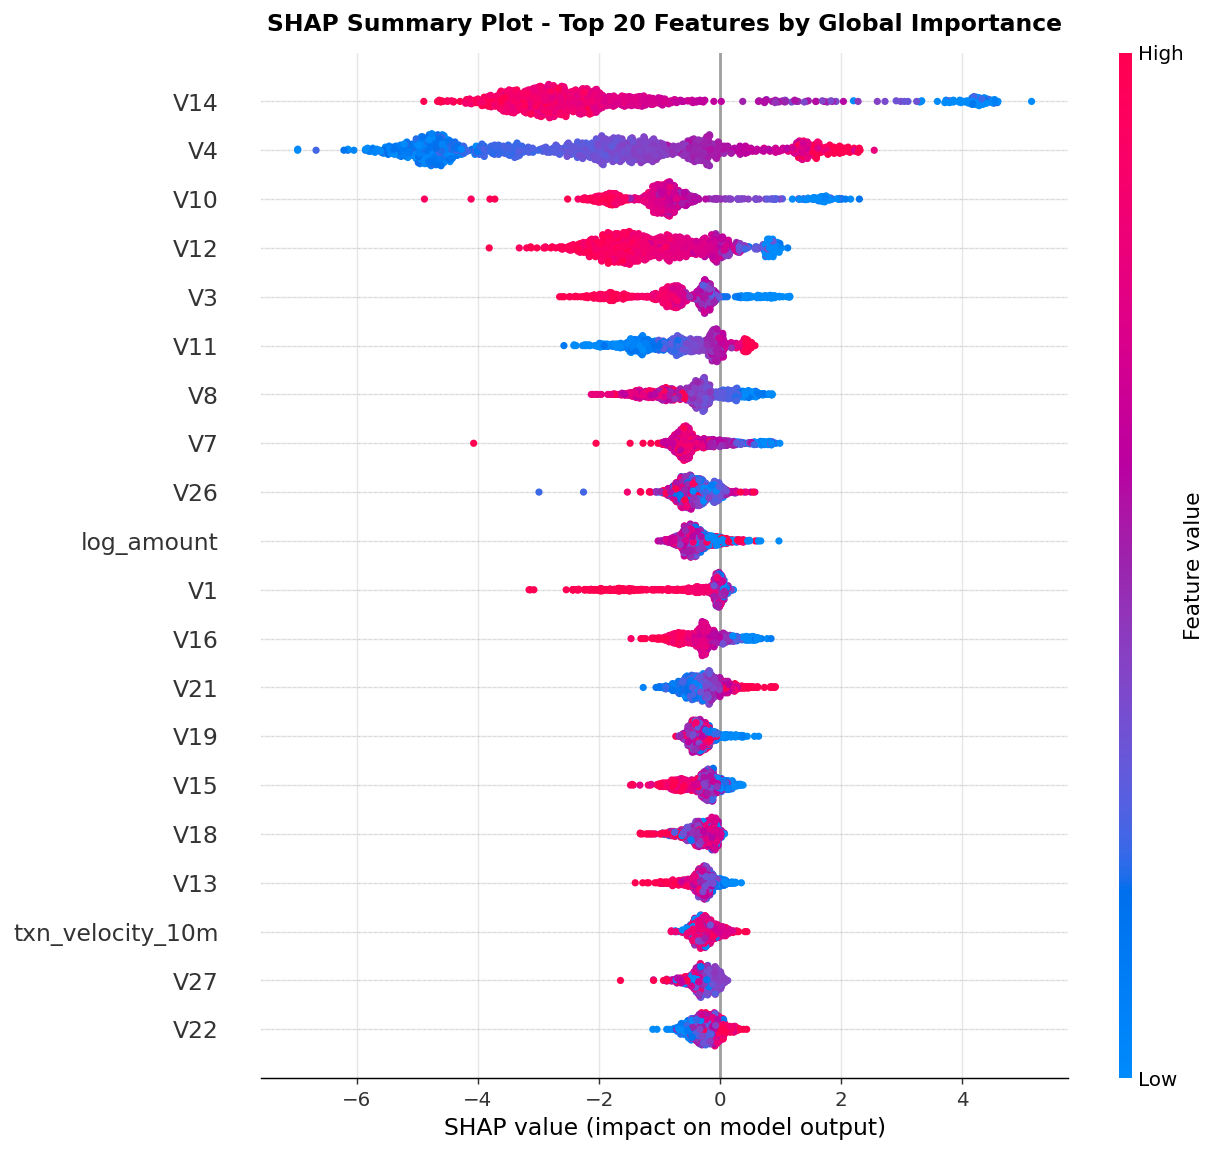

Saved: shap_01_summary_plot.png

How to read:
  Top features = most impactful on fraud score
  Red dot far right = high feature value INCREASES fraud risk
  Blue dot far left = low feature value DECREASES fraud risk


In [52]:
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names = FEATURES,
    max_display   = 20,
    show          = False,
    plot_size     = None
)
plt.title('SHAP Summary Plot - Top 20 Features by Global Importance',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_01_summary_plot.png', bbox_inches='tight')
plt.show()
print('Saved: shap_01_summary_plot.png')
print()
print('How to read:')
print('  Top features = most impactful on fraud score')
print('  Red dot far right = high feature value INCREASES fraud risk')
print('  Blue dot far left = low feature value DECREASES fraud risk')

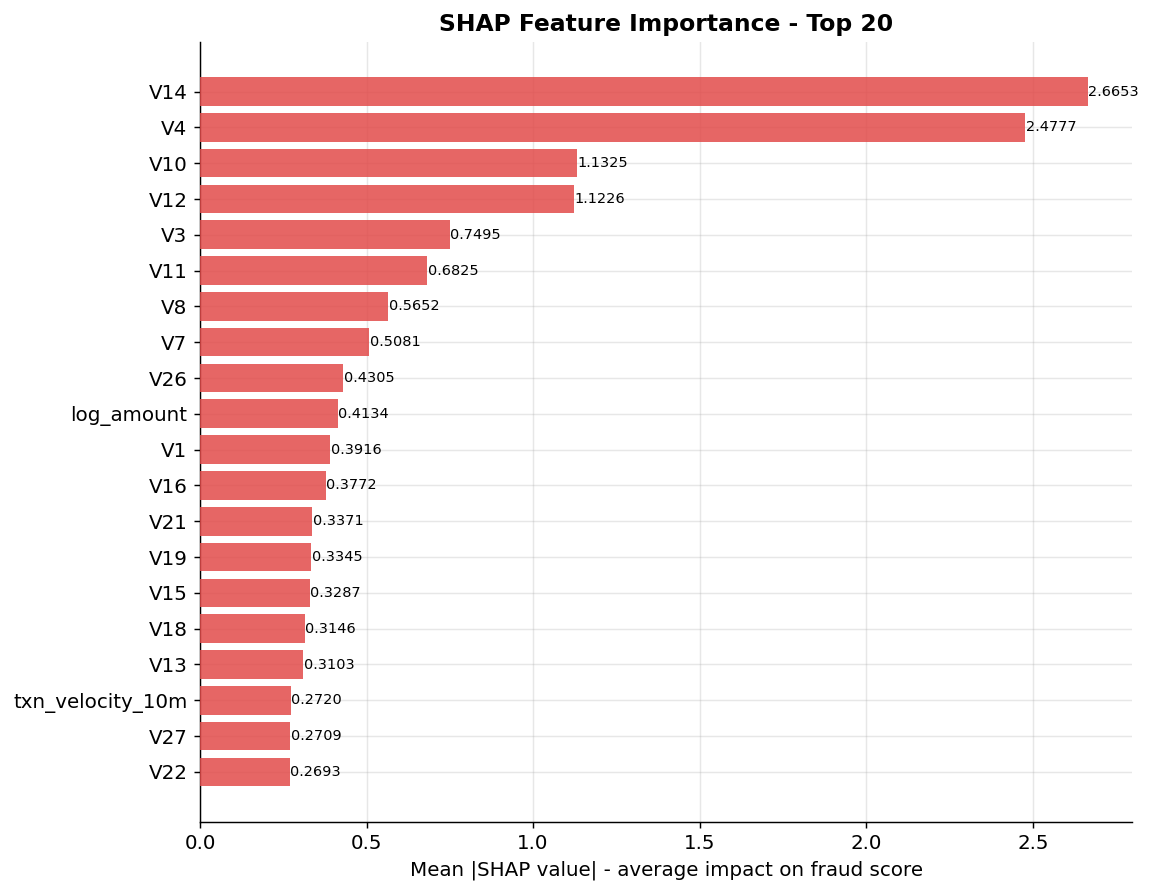

Saved: shap_02_bar_importance.png

Top 5 features:
feature  importance
    V14    2.665280
     V4    2.477715
    V10    1.132470
    V12    1.122618
     V3    0.749489


In [53]:
# Mean |SHAP| per feature - clean bar chart version
mean_shap = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(mean_shap['feature'][::-1],
               mean_shap['importance'][::-1],
               color=FRAUD_COLOR, alpha=0.85, zorder=3)
ax.set_xlabel('Mean |SHAP value| - average impact on fraud score')
ax.set_title('SHAP Feature Importance - Top 20')

for bar, val in zip(bars, mean_shap['importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('shap_02_bar_importance.png', bbox_inches='tight')
plt.show()
print('Saved: shap_02_bar_importance.png')
print()
print('Top 5 features:')
print(mean_shap[['feature','importance']].head(5).to_string(index=False))


## 4. SHAP Waterfall Plot - Explain ONE Fraud Transaction

Each bar shows how much each feature pushed the score UP (red) or DOWN (blue) from the baseline.

In [54]:
# Pick highest confidence fraud prediction 
fraud_mask   = y_shap == 1
fraud_probs  = xgb_model.predict_proba(X_shap[fraud_mask])[:, 1]
top_fraud_idx= np.argmax(fraud_probs)         # index within fraud subset
global_idx   = np.where(fraud_mask)[0][top_fraud_idx]  # index in X_shap

prob_val = fraud_probs[top_fraud_idx]
amt_val  = X_shap.iloc[global_idx]['log_amount']

print(f'Selected transaction:')
print(f'  Index in sample : {global_idx}')
print(f'  Fraud prob      : {prob_val:.4f}  ({prob_val*100:.2f}%)')
print(f'  Actual class    : FRAUD')
print()
print('Top feature values for this transaction:')
top5 = mean_shap['feature'].head(5).tolist()
for f in top5:
    val  = X_shap.iloc[global_idx][f]
    sv   = shap_values.values[global_idx, FEATURES.index(f)]
    print(f'  {f:22s}: value={val:8.4f}  SHAP={sv:+.4f}')

Selected transaction:
  Index in sample : 705
  Fraud prob      : 1.0000  (100.00%)
  Actual class    : FRAUD

Top feature values for this transaction:
  V14                   : value=-13.6949  SHAP=+4.5018
  V4                    : value=  8.9251  SHAP=+1.6281
  V10                   : value=-12.8057  SHAP=+1.8278
  V12                   : value=-13.0642  SHAP=+0.9184
  V3                    : value=-13.2717  SHAP=+0.8410


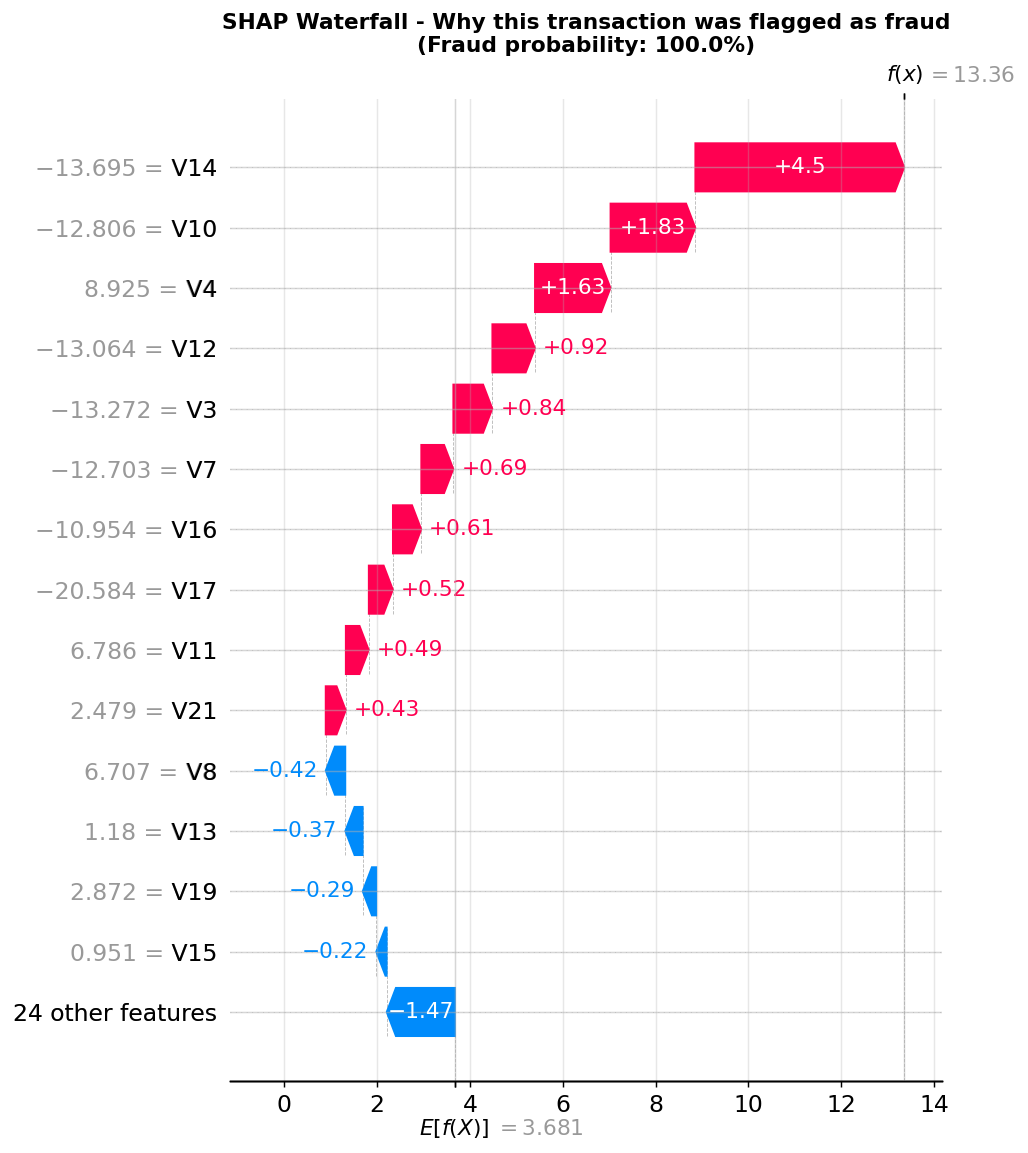

Saved: shap_03_waterfall_fraud.png

How to read:
  E[f(x)] = base value (avg model output across all transactions)
  f(x)    = this transaction fraud probability
  Red bars = features pushing score UP (more fraud risk)
  Blue bars = features pushing score DOWN (less fraud risk)


In [55]:
# Waterfall plot 
plt.figure(figsize=(10, 7))
shap.waterfall_plot(
    shap_values[global_idx],
    max_display = 15,
    show        = False
)
plt.title(f'SHAP Waterfall - Why this transaction was flagged as fraud\n'
          f'(Fraud probability: {prob_val*100:.1f}%)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_03_waterfall_fraud.png', bbox_inches='tight')
plt.show()
print('Saved: shap_03_waterfall_fraud.png')
print()
print('How to read:')
print('  E[f(x)] = base value (avg model output across all transactions)')
print('  f(x)    = this transaction fraud probability')
print('  Red bars = features pushing score UP (more fraud risk)')
print('  Blue bars = features pushing score DOWN (less fraud risk)')


## 5. SHAP Waterfall - One Legitimate Transaction

Shows a legitimate transaction being correctly cleared - equally important for explaining false positive risk.

Selected transaction:
  Fraud prob : 0.0000  (0.000%)
  Actual     : LEGITIMATE


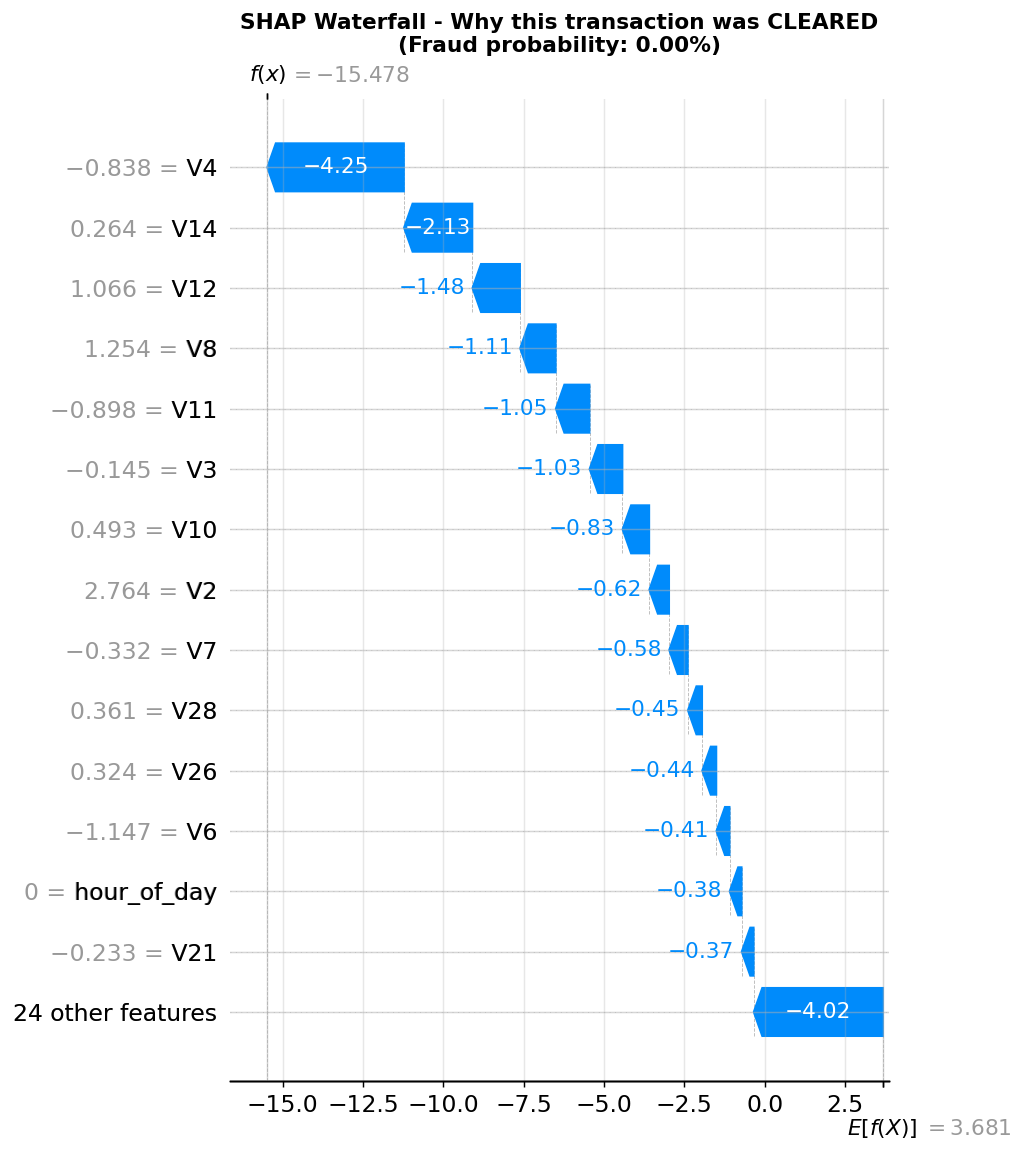

Saved: shap_04_waterfall_legit.png


In [56]:
# Pick a legitimate transaction correctly classified 
legit_mask    = y_shap == 0
legit_probs   = xgb_model.predict_proba(X_shap[legit_mask])[:, 1]
low_prob_idx  = np.argmin(legit_probs)       # lowest fraud prob = confident legit
global_legit  = np.where(legit_mask)[0][low_prob_idx]

legit_prob = legit_probs[low_prob_idx]

print(f'Selected transaction:')
print(f'  Fraud prob : {legit_prob:.4f}  ({legit_prob*100:.3f}%)')
print(f'  Actual     : LEGITIMATE')

plt.figure(figsize=(10, 7))
shap.waterfall_plot(
    shap_values[global_legit],
    max_display = 15,
    show        = False
)
plt.title(f'SHAP Waterfall - Why this transaction was CLEARED\n'
          f'(Fraud probability: {legit_prob*100:.2f}%)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_04_waterfall_legit.png', bbox_inches='tight')
plt.show()
print('Saved: shap_04_waterfall_legit.png')


## 6. SHAP Dependence Plots - Top 3 Features

Shows how a feature's value affects its SHAP contribution.  
Color = interaction with another top feature (auto-selected by SHAP).

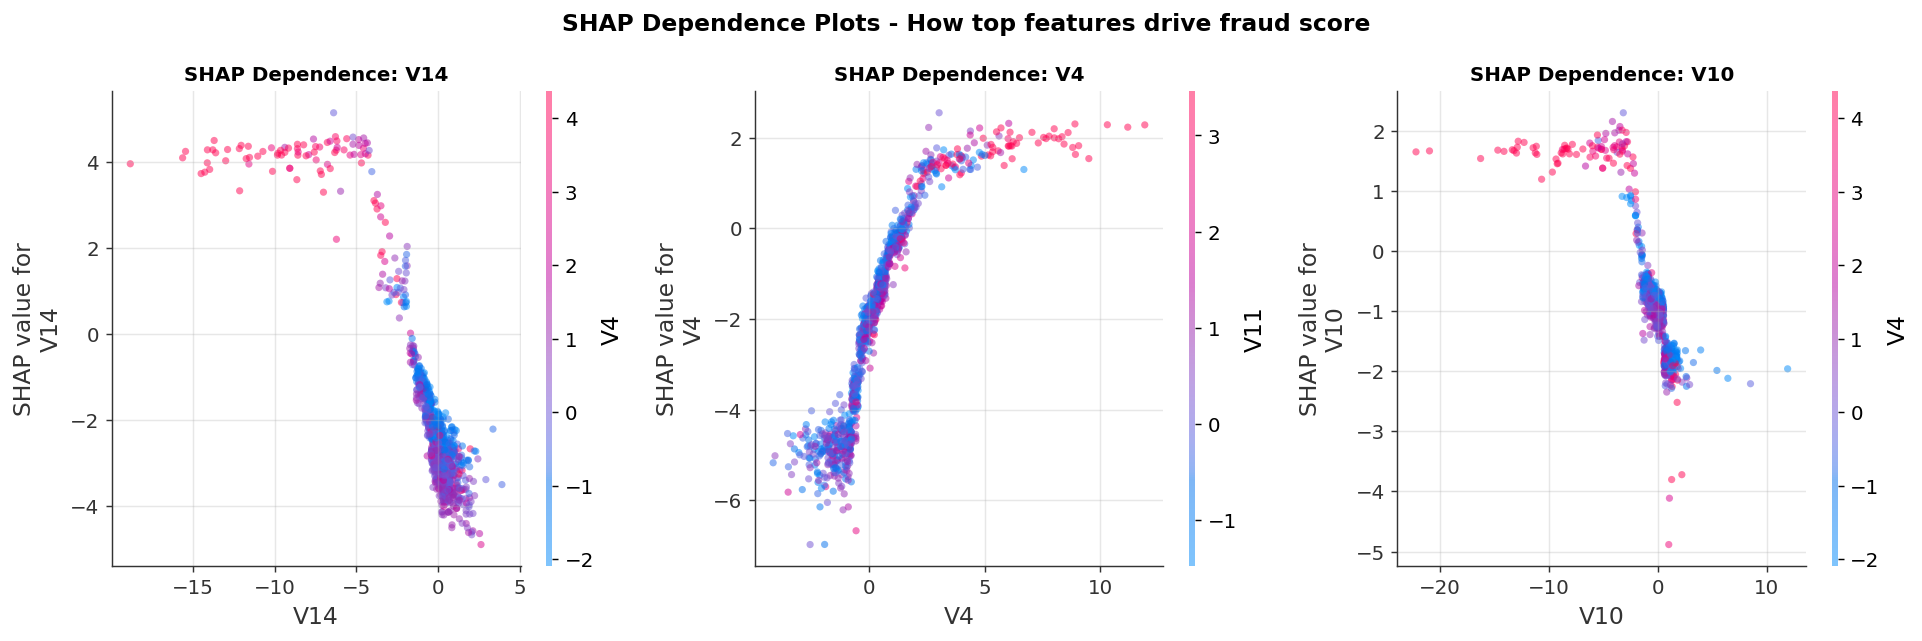

Saved: shap_05_dependence_plots.png

How to read:
  x-axis = feature value
  y-axis = SHAP value (impact on fraud score)
  color  = value of interacting feature (auto-selected)
  Pattern = the relationship the model learned


In [57]:
top3 = mean_shap['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat in zip(axes, top3):
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_shap,
        ax       = ax,
        show     = False,
        alpha    = 0.5
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11)

plt.suptitle('SHAP Dependence Plots - How top features drive fraud score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_05_dependence_plots.png', bbox_inches='tight')
plt.show()
print('Saved: shap_05_dependence_plots.png')
print()
print('How to read:')
print('  x-axis = feature value')
print('  y-axis = SHAP value (impact on fraud score)')
print('  color  = value of interacting feature (auto-selected)')
print('  Pattern = the relationship the model learned')


## 7. SHAP - Fraud vs Legitimate Comparison

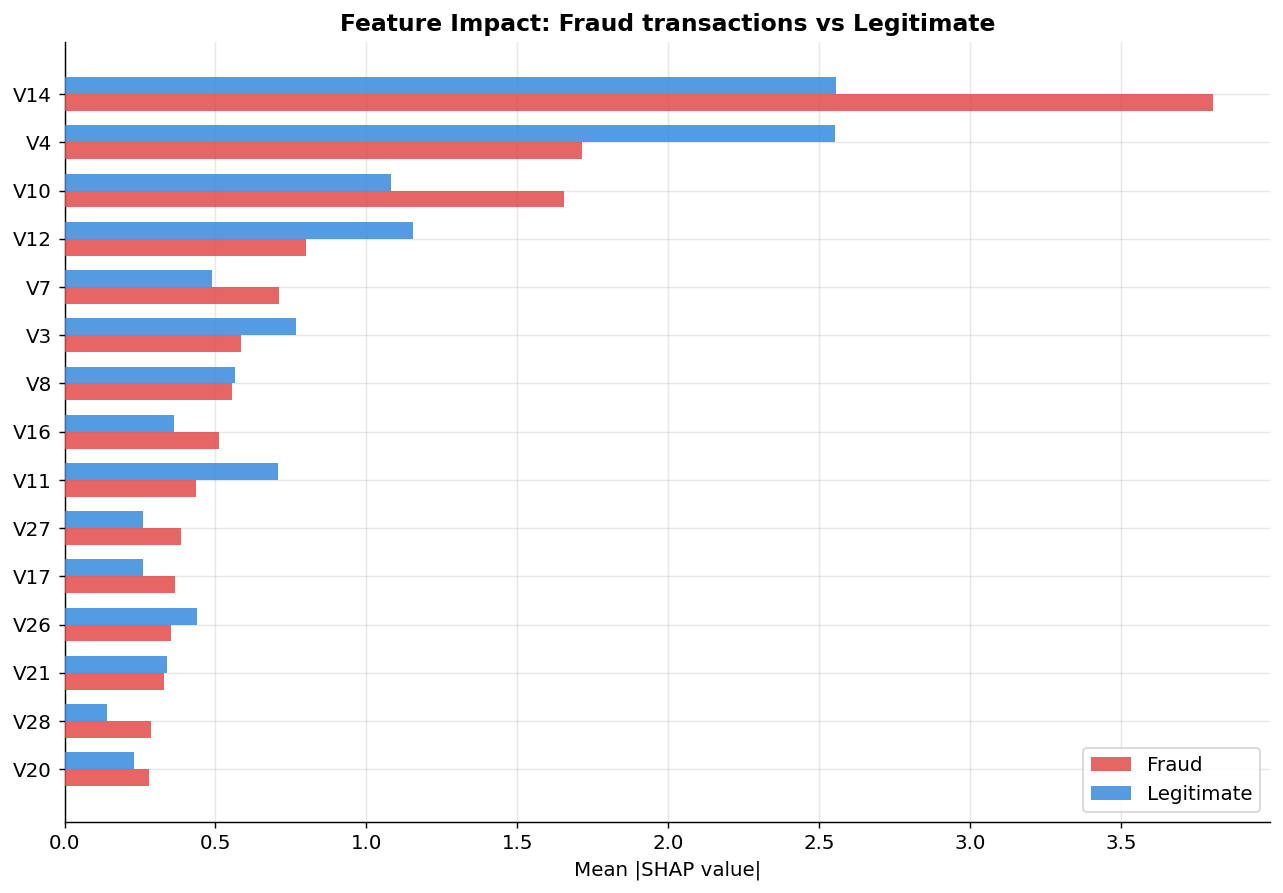

Saved: shap_06_fraud_vs_legit.png


In [58]:
# Mean |SHAP| for fraud vs legit separately
fraud_shap = np.abs(shap_values.values[y_shap == 1]).mean(axis=0)
legit_shap = np.abs(shap_values.values[y_shap == 0]).mean(axis=0)

shap_compare = pd.DataFrame({
    'feature'    : FEATURES,
    'fraud_shap' : fraud_shap,
    'legit_shap' : legit_shap
}).sort_values('fraud_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
x     = np.arange(len(shap_compare))
width = 0.35

ax.barh(x + width/2, shap_compare['fraud_shap'],
        height=width, color=FRAUD_COLOR, alpha=0.85, label='Fraud', zorder=3)
ax.barh(x - width/2, shap_compare['legit_shap'],
        height=width, color=LEGIT_COLOR, alpha=0.85, label='Legitimate', zorder=3)

ax.set_yticks(x)
ax.set_yticklabels(shap_compare['feature'])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Impact: Fraud transactions vs Legitimate')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('shap_06_fraud_vs_legit.png', bbox_inches='tight')
plt.show()
print('Saved: shap_06_fraud_vs_legit.png')


## 8. Business Explanation - Plain English SHAP

In [59]:
# Plain English explanation of the flagged fraud transaction 
print('=' * 60)
print('  PLAIN ENGLISH EXPLANATION')
print('  (Transaction flagged as fraud)')
print('=' * 60)

feat_shap = pd.DataFrame({
    'feature'   : FEATURES,
    'shap_value': shap_values.values[global_idx],
    'feat_value': X_shap.iloc[global_idx].values
}).sort_values('shap_value', ascending=False)

top_risk    = feat_shap.head(3)
top_reduces = feat_shap.tail(3)

print(f'\n  Fraud probability : {prob_val*100:.1f}%')
print(f'  Decision          : BLOCK')
print()
print('  Top factors INCREASING fraud risk:')
for _, row in top_risk.iterrows():
    print(f'    {row["feature"]:22s} (SHAP={row["shap_value"]:+.4f})')
print()
print('  Factors that REDUCED fraud score:')
for _, row in top_reduces.iterrows():
    print(f'    {row["feature"]:22s} (SHAP={row["shap_value"]:+.4f})')
print()
print('=' * 60)
print()
print('Files saved:')
for i, name in enumerate([
    'SHAP summary plot',
    'SHAP bar importance',
    'Waterfall - fraud transaction',
    'Waterfall - legit transaction',
    'Dependence plots (top 3)',
    'Fraud vs legit SHAP comparison'
], 1):
    print(f'  shap_0{i}_{name.lower().replace(" ","_")[:25]}.png')
print()
print('NEXT -> Phase 7: Business ROI & Cost Analysis')

  PLAIN ENGLISH EXPLANATION
  (Transaction flagged as fraud)

  Fraud probability : 100.0%
  Decision          : BLOCK

  Top factors INCREASING fraud risk:
    V14                    (SHAP=+4.5018)
    V10                    (SHAP=+1.8278)
    V4                     (SHAP=+1.6281)

  Factors that REDUCED fraud score:
    V19                    (SHAP=-0.2927)
    V13                    (SHAP=-0.3737)
    V8                     (SHAP=-0.4234)


Files saved:
  shap_01_shap_summary_plot.png
  shap_02_shap_bar_importance.png
  shap_03_waterfall_-_fraud_transac.png
  shap_04_waterfall_-_legit_transac.png
  shap_05_dependence_plots_(top_3).png
  shap_06_fraud_vs_legit_shap_compa.png

NEXT -> Phase 7: Business ROI & Cost Analysis


# Phase 7: Business ROI & Cost Analysis

**Goal:** Translate model metrics into business dollars - find the threshold that minimises total cost, not just maximises F1.

**Input:** `scored_transactions.csv` from Phase 5

In [71]:
# Load scored test set
scored = pd.read_csv('scored_transactions.csv')

with open('phase4_config.json') as f:
    cfg = json.load(f)
BEST_THRESH = cfg['best_threshold']

y_test = scored['actual_class']
y_prob = scored['fraud_prob']
amounts= scored['Amount']

print(f'Test set      : {len(scored):,} transactions')
print(f'Fraud cases   : {y_test.sum():,}')
print(f'Total amount  : ${amounts.sum():,.2f}')
print(f'Fraud amount  : ${amounts[y_test==1].sum():,.2f}')
print(f'Best threshold: {BEST_THRESH:.4f}')

Test set      : 56,962 transactions
Fraud cases   : 98
Total amount  : $5,048,532.86
Fraud amount  : $10,373.77
Best threshold: 0.4000


## 1. Define Cost Matrix

In [72]:
# Cost assumptions (realistic for credit card fraud) 
# These are adjustable - sensitivity analysis in Section 5

COST_FN = 150   # False Negative: avg fraud loss per missed transaction
COST_FP = 15    # False Positive: ops cost ($5) + customer friction ($10)
COST_TP = 0     # True Positive:  fraud caught = $0 net cost
COST_TN = 0     # True Negative:  legit cleared = $0 cost

print('Cost Matrix:')
print(f'  False Negative (missed fraud)  : ${COST_FN} per transaction')
print(f'  False Positive (blocked legit) : ${COST_FP} per transaction')
print(f'  True Positive  (caught fraud)  : ${COST_TP}')
print(f'  True Negative  (cleared legit) : ${COST_TN}')
print()
print(f'Implication: FN is {COST_FN/COST_FP:.0f}x more expensive than FP')
print(f'- Model should lean toward recall (catching fraud)')
print(f'  but not so aggressively it generates huge FP costs')

Cost Matrix:
  False Negative (missed fraud)  : $150 per transaction
  False Positive (blocked legit) : $15 per transaction
  True Positive  (caught fraud)  : $0
  True Negative  (cleared legit) : $0

Implication: FN is 10x more expensive than FP
- Model should lean toward recall (catching fraud)
  but not so aggressively it generates huge FP costs


## 2. Total Cost at Every Threshold

In [73]:
thresholds = np.arange(0.01, 0.99, 0.01)
results    = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost  = (fn * COST_FN) + (fp * COST_FP)
    fn_cost     = fn * COST_FN
    fp_cost     = fp * COST_FP
    fraud_saved = tp * COST_FN   # fraud prevented

    results.append({
        'threshold'   : round(t, 2),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision'   : precision_score(y_test, y_pred, zero_division=0),
        'recall'      : recall_score(y_test, y_pred, zero_division=0),
        'f1'          : f1_score(y_test, y_pred, zero_division=0),
        'fn_cost'     : fn_cost,
        'fp_cost'     : fp_cost,
        'total_cost'  : total_cost,
        'fraud_saved' : fraud_saved,
    })

cost_df = pd.DataFrame(results)

# Find optimal threshold 
opt_idx   = cost_df['total_cost'].idxmin()
opt_row   = cost_df.loc[opt_idx]
opt_thresh= opt_row['threshold']

print(f'Optimal threshold (min cost) : {opt_thresh}')
print(f'  Total cost   : ${opt_row["total_cost"]:,.0f}')
print(f'  FN cost      : ${opt_row["fn_cost"]:,.0f}  ({int(opt_row["fn"])} missed fraud)')
print(f'  FP cost      : ${opt_row["fp_cost"]:,.0f}  ({int(opt_row["fp"])} blocked legit)')
print(f'  Fraud saved  : ${opt_row["fraud_saved"]:,.0f}')
print(f'  Precision    : {opt_row["precision"]:.4f}')
print(f'  Recall       : {opt_row["recall"]:.4f}')
print(f'  F1           : {opt_row["f1"]:.4f}')
print()

# Compare with default 0.5
def_row = cost_df[cost_df['threshold'] == 0.5].iloc[0]
print(f'Default threshold 0.5:')
print(f'  Total cost   : ${def_row["total_cost"]:,.0f}')
print(f'  Cost saving  : ${def_row["total_cost"] - opt_row["total_cost"]:,.0f} by tuning threshold')

Optimal threshold (min cost) : 0.09
  Total cost   : $1,950
  FN cost      : $1,650  (11 missed fraud)
  FP cost      : $300  (20 blocked legit)
  Fraud saved  : $13,050
  Precision    : 0.8131
  Recall       : 0.8878
  F1           : 0.8488

Default threshold 0.5:
  Total cost   : $2,715
  Cost saving  : $765 by tuning threshold


## 3. Cost Curve Visualisation

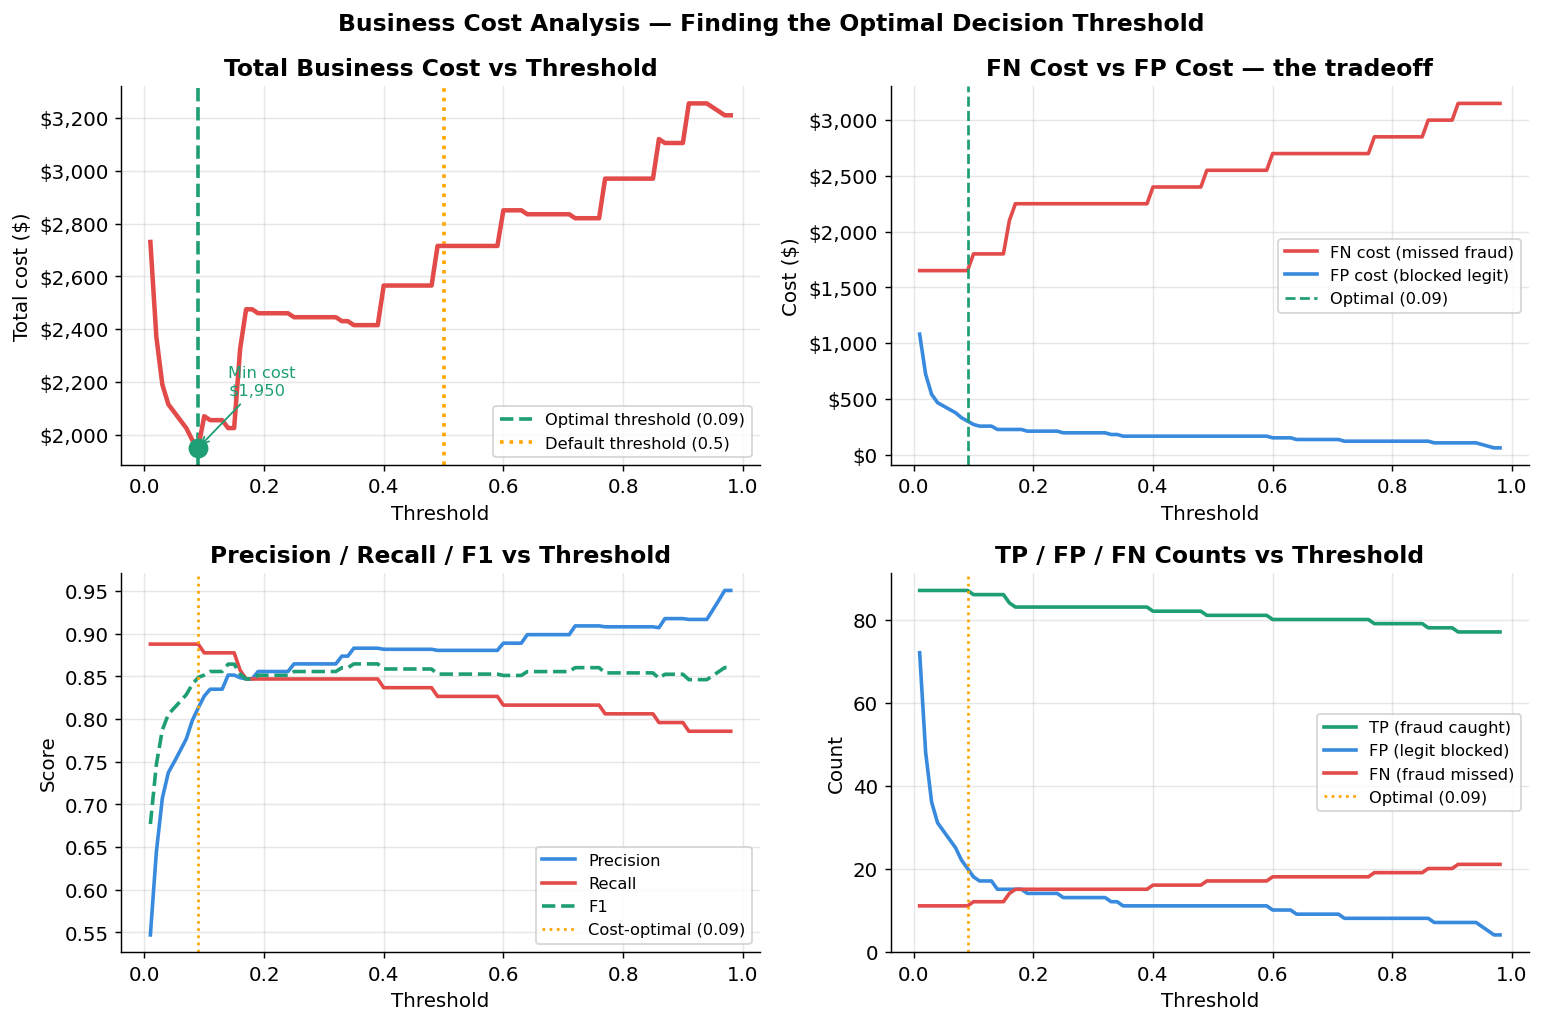

Saved: roi_01_cost_analysis.png


In [74]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top left: Total cost curve 
ax = axes[0, 0]
ax.plot(cost_df['threshold'], cost_df['total_cost'],
        color=FRAUD_COLOR, linewidth=2.5, zorder=3)
ax.axvline(opt_thresh, color=ACCENT_COLOR, linestyle='--',
           linewidth=2, label=f'Optimal threshold ({opt_thresh})')
ax.axvline(0.5, color=AMBER_COLOR, linestyle=':',
           linewidth=2, label='Default threshold (0.5)')
ax.scatter([opt_thresh], [opt_row['total_cost']],
           color=ACCENT_COLOR, s=100, zorder=5)
ax.annotate(f'Min cost\n${opt_row["total_cost"]:,.0f}',
            xy=(opt_thresh, opt_row['total_cost']),
            xytext=(opt_thresh+0.05, opt_row['total_cost']+200),
            fontsize=9, color=ACCENT_COLOR,
            arrowprops=dict(arrowstyle='->', color=ACCENT_COLOR))
ax.set_xlabel('Threshold')
ax.set_ylabel('Total cost ($)')
ax.set_title('Total Business Cost vs Threshold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(fontsize=9)

# Top right: FN vs FP cost breakdown 
ax = axes[0, 1]
ax.plot(cost_df['threshold'], cost_df['fn_cost'],
        color=FRAUD_COLOR, linewidth=2, label='FN cost (missed fraud)')
ax.plot(cost_df['threshold'], cost_df['fp_cost'],
        color=LEGIT_COLOR, linewidth=2, label='FP cost (blocked legit)')
ax.axvline(opt_thresh, color=ACCENT_COLOR, linestyle='--',
           linewidth=1.5, label=f'Optimal ({opt_thresh})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Cost ($)')
ax.set_title('FN Cost vs FP Cost — the tradeoff')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(fontsize=9)

# Bottom left: Precision / Recall / F1 
ax = axes[1, 0]
ax.plot(cost_df['threshold'], cost_df['precision'],
        color=LEGIT_COLOR, linewidth=2, label='Precision')
ax.plot(cost_df['threshold'], cost_df['recall'],
        color=FRAUD_COLOR, linewidth=2, label='Recall')
ax.plot(cost_df['threshold'], cost_df['f1'],
        color=ACCENT_COLOR, linewidth=2, linestyle='--', label='F1')
ax.axvline(opt_thresh, color=AMBER_COLOR, linestyle=':',
           linewidth=1.5, label=f'Cost-optimal ({opt_thresh})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend(fontsize=9)

# Bottom right: TP / FP / FN counts 
ax = axes[1, 1]
ax.plot(cost_df['threshold'], cost_df['tp'],
        color=ACCENT_COLOR, linewidth=2, label='TP (fraud caught)')
ax.plot(cost_df['threshold'], cost_df['fp'],
        color=LEGIT_COLOR,  linewidth=2, label='FP (legit blocked)')
ax.plot(cost_df['threshold'], cost_df['fn'],
        color=FRAUD_COLOR,  linewidth=2, label='FN (fraud missed)')
ax.axvline(opt_thresh, color=AMBER_COLOR, linestyle=':',
           linewidth=1.5, label=f'Optimal ({opt_thresh})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Count')
ax.set_title('TP / FP / FN Counts vs Threshold')
ax.legend(fontsize=9)

plt.suptitle('Business Cost Analysis — Finding the Optimal Decision Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roi_01_cost_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: roi_01_cost_analysis.png')


## 4. ROI Summary - What the Model Saves

In [75]:
# Scenario comparison 
# Scenario A: No model (catch nothing)
total_fraud_loss = y_test.sum() * COST_FN

# Scenario B: Default threshold 0.5
def_cost = def_row['total_cost']
def_saved= def_row['fraud_saved']

# Scenario C: Optimal threshold
opt_cost  = opt_row['total_cost']
opt_saved = opt_row['fraud_saved']

scenarios = pd.DataFrame({
    'Scenario': [
        'No model (catch nothing)',
        'Model @ default 0.5',
        f'Model @ optimal {opt_thresh} (cost-tuned)',
    ],
    'Fraud Caught': [
        0,
        int(def_row['tp']),
        int(opt_row['tp']),
    ],
    'Fraud Missed': [
        int(y_test.sum()),
        int(def_row['fn']),
        int(opt_row['fn']),
    ],
    'Legit Blocked': [
        0,
        int(def_row['fp']),
        int(opt_row['fp']),
    ],
    'FN Cost ($)': [
        total_fraud_loss,
        int(def_row['fn_cost']),
        int(opt_row['fn_cost']),
    ],
    'FP Cost ($)': [
        0,
        int(def_row['fp_cost']),
        int(opt_row['fp_cost']),
    ],
    'Total Cost ($)': [
        total_fraud_loss,
        int(def_row['total_cost']),
        int(opt_row['total_cost']),
    ],
})

print('ROI Scenario Comparison:')
print(scenarios.to_string(index=False))
print()
print(f'Cost saving vs no model    : ${total_fraud_loss - opt_cost:,.0f}')
print(f'Cost saving vs default 0.5 : ${def_cost - opt_cost:,.0f}')
print(f'Fraud value prevented      : ${opt_saved:,.0f}')

ROI Scenario Comparison:
                         Scenario  Fraud Caught  Fraud Missed  Legit Blocked  FN Cost ($)  FP Cost ($)  Total Cost ($)
         No model (catch nothing)             0            98              0        14700            0           14700
              Model @ default 0.5            81            17             11         2550          165            2715
Model @ optimal 0.09 (cost-tuned)            87            11             20         1650          300            1950

Cost saving vs no model    : $12,750
Cost saving vs default 0.5 : $765
Fraud value prevented      : $13,050


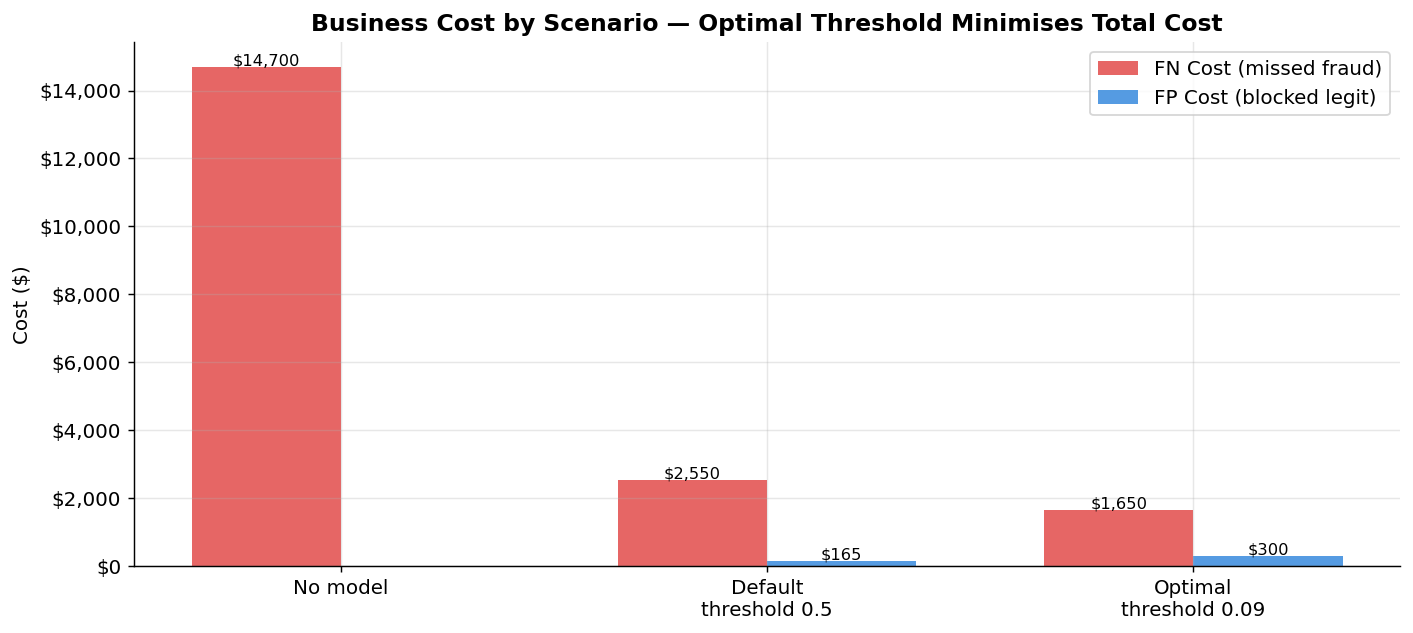

Saved: roi_02_scenario_comparison.png


In [76]:
# ROI bar chart
fig, ax = plt.subplots(figsize=(11, 5))

labels  = ['No model', 'Default\nthreshold 0.5',
           f'Optimal\nthreshold {opt_thresh}']
fn_costs= [total_fraud_loss, def_row['fn_cost'], opt_row['fn_cost']]
fp_costs= [0, def_row['fp_cost'], opt_row['fp_cost']]

x     = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, fn_costs, width,
               label='FN Cost (missed fraud)',  color=FRAUD_COLOR, alpha=0.85)
bars2 = ax.bar(x + width/2, fp_costs, width,
               label='FP Cost (blocked legit)', color=LEGIT_COLOR, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Cost ($)')
ax.set_title('Business Cost by Scenario — Optimal Threshold Minimises Total Cost')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'${bar.get_height():,.0f}', ha='center', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'${bar.get_height():,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('roi_02_scenario_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: roi_02_scenario_comparison.png')


## 5. Sensitivity Analysis - What if costs change?

The optimal threshold shifts depending on assumed costs.  
This shows how robust the recommendation is.

In [77]:
fn_cost_scenarios = [50, 100, 150, 200, 300]
fp_cost_scenarios = [5,  10,  15,  20,  30]

sensitivity = []
thresholds  = np.arange(0.01, 0.99, 0.01)

for fn_c in fn_cost_scenarios:
    for fp_c in fp_cost_scenarios:
        costs = []
        for t in thresholds:
            y_pred = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
            costs.append(fn * fn_c + fp * fp_c)
        best_t = thresholds[np.argmin(costs)]
        sensitivity.append({
            'FN cost': fn_c,
            'FP cost': fp_c,
            'Ratio'  : fn_c // fp_c,
            'Optimal threshold': round(best_t, 2),
            'Min total cost': round(min(costs), 0)
        })

sens_df = pd.DataFrame(sensitivity)
print('Sensitivity Analysis - Optimal threshold across cost assumptions:')
print(sens_df.to_string(index=False))

Sensitivity Analysis - Optimal threshold across cost assumptions:
 FN cost  FP cost  Ratio  Optimal threshold  Min total cost
      50        5     10               0.09             650
      50       10      5               0.09             750
      50       15      3               0.14             825
      50       20      2               0.14             900
      50       30      1               0.14            1050
     100        5     20               0.09            1200
     100       10     10               0.09            1300
     100       15      6               0.09            1400
     100       20      5               0.09            1500
     100       30      3               0.14            1650
     150        5     30               0.09            1750
     150       10     15               0.09            1850
     150       15     10               0.09            1950
     150       20      7               0.09            2050
     150       30      5          

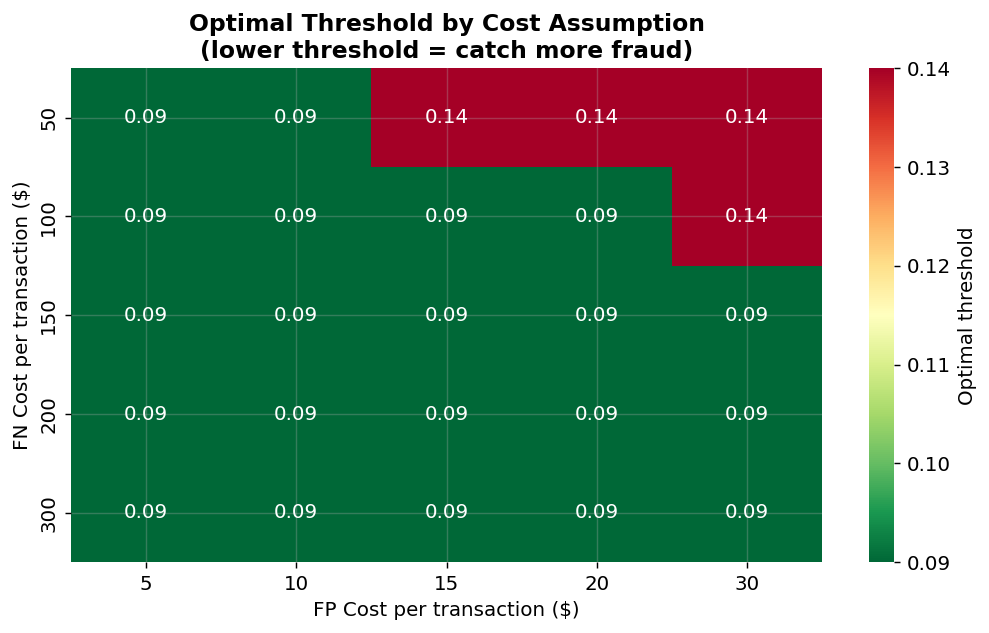

Saved: roi_03_sensitivity_heatmap.png


In [78]:
# Heatmap of optimal threshold vs cost assumptions 
pivot = sens_df.pivot(index='FN cost', columns='FP cost',
                      values='Optimal threshold')

import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Optimal threshold'})
ax.set_title('Optimal Threshold by Cost Assumption\n'
             '(lower threshold = catch more fraud)',
             fontweight='bold')
ax.set_xlabel('FP Cost per transaction ($)')
ax.set_ylabel('FN Cost per transaction ($)')
plt.tight_layout()
plt.savefig('roi_03_sensitivity_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: roi_03_sensitivity_heatmap.png')


## 6. Export for Tableau Dashboard

In [79]:
# Add business columns for Tableau
opt_pred = (y_prob >= opt_thresh).astype(int)

tableau_df = scored.copy()
tableau_df['decision_threshold'] = opt_thresh
tableau_df['predicted_fraud_opt']= opt_pred
tableau_df['outcome'] = np.select(
    [
        (y_test==1) & (opt_pred==1),
        (y_test==0) & (opt_pred==1),
        (y_test==1) & (opt_pred==0),
        (y_test==0) & (opt_pred==0),
    ],
    ['True Positive', 'False Positive', 'False Negative', 'True Negative'],
     default='Unknown'  # Added string default value instead of numeric 0
)
tableau_df['business_cost'] = np.where(
    tableau_df['outcome'] == 'False Negative', COST_FN,
    np.where(tableau_df['outcome'] == 'False Positive', COST_FP, 0)
)
tableau_df['risk_band'] = pd.cut(
    tableau_df['fraud_prob'],
    bins  = [0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels= ['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

tableau_df.to_csv('tableau_fraud_data.csv', index=False)
print(f'Saved: tableau_fraud_data.csv')
print(f'  Rows     : {len(tableau_df):,}')
print(f'  Columns  : {tableau_df.shape[1]}')
print()
print('Outcome breakdown:')
print(tableau_df['outcome'].value_counts().to_string())
print()
print('Risk band breakdown:')
print(tableau_df['risk_band'].value_counts().sort_index().to_string())

Saved: tableau_fraud_data.csv
  Rows     : 56,962
  Columns  : 47

Outcome breakdown:
outcome
True Negative     56844
True Positive        87
False Positive       20
False Negative       11

Risk band breakdown:
risk_band
Very Low     56865
Low              4
Medium           3
High             3
Very High       87


---
## 7. Final Project Summary

In [80]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_opt = (y_prob >= opt_thresh).astype(int)

print('=' * 62)
print('  CREDIT CARD FRAUD DETECTION — FULL PROJECT SUMMARY')
print('=' * 62)
print()
print('  DATASET')
print(f'    Transactions   : 284,807')
print(f'    Fraud cases    : 492  (0.1727%)')
print(f'    Imbalance      : 577:1')
print()
print('  PIPELINE')
print(f'    SQL Phase 1    : MySQL — 5 queries + 3 views')
print(f'    EDA Phase 2    : 8 charts — time, amount, correlations')
print(f'    Features Phase 3  : 8 engineered features (velocity, cyclical, z-score)')
print(f'    Imbalance Phase 4 : scale_pos_weight + threshold tuning')
print(f'    Model Phase 5  : XGBoost (GridSearchCV, 5-fold stratified CV)')
print(f'    SHAP Phase 6   : 6 explainability charts')
print(f'    ROI Phase 7    : Cost matrix + sensitivity analysis')
print()
print('  MODEL PERFORMANCE')
print(f'    AUC-ROC        : {roc_auc_score(y_test, y_prob):.4f}')
print(f'    AUC-PR         : {average_precision_score(y_test, y_prob):.4f}')
print(f'    Precision      : {precision_score(y_test, y_pred_opt):.4f}')
print(f'    Recall         : {recall_score(y_test, y_pred_opt):.4f}')
print(f'    F1             : {f1_score(y_test, y_pred_opt):.4f}')
print(f'    Threshold      : {opt_thresh} (cost-optimised)')
print()
print('  BUSINESS IMPACT')
print(f'    Cost vs no model   : ${total_fraud_loss - opt_cost:,.0f} saved')
print(f'    Fraud prevented    : ${opt_saved:,.0f}')
print(f'    FP cost            : ${opt_row["fp_cost"]:,.0f}')
print(f'    Net saving         : ${total_fraud_loss - opt_cost:,.0f}')
print()
print('  DELIVERABLES')
print('    fraud_model_xgb.pkl')
print('    scored_transactions.csv')
print('    tableau_fraud_data.csv   ← Tableau Phase 8 input')
print('    phase4_config.json')
print()
print('  NEXT -> Phase 8: Tableau Dashboard')
print('=' * 62)

  CREDIT CARD FRAUD DETECTION — FULL PROJECT SUMMARY

  DATASET
    Transactions   : 284,807
    Fraud cases    : 492  (0.1727%)
    Imbalance      : 577:1

  PIPELINE
    SQL Phase 1    : MySQL — 5 queries + 3 views
    EDA Phase 2    : 8 charts — time, amount, correlations
    Features Phase 3  : 8 engineered features (velocity, cyclical, z-score)
    Imbalance Phase 4 : scale_pos_weight + threshold tuning
    Model Phase 5  : XGBoost (GridSearchCV, 5-fold stratified CV)
    SHAP Phase 6   : 6 explainability charts
    ROI Phase 7    : Cost matrix + sensitivity analysis

  MODEL PERFORMANCE
    AUC-ROC        : 0.9766
    AUC-PR         : 0.8804
    Precision      : 0.8131
    Recall         : 0.8878
    F1             : 0.8488
    Threshold      : 0.09 (cost-optimised)

  BUSINESS IMPACT
    Cost vs no model   : $12,750 saved
    Fraud prevented    : $13,050
    FP cost            : $300
    Net saving         : $12,750

  DELIVERABLES
    fraud_model_xgb.pkl
    scored_transactions